In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [2]:
initCs = {}
for v in const.VARIATIONS:
    initCs[v] = {}
    for dco in const.DCO_TYPES:
        initCs[v][dco] = pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/{v}/{dco}_at_formation.h5", key="initC")
        print(f"Loaded {v}/{dco}_at_formation.h5")

Loaded fiducial/BHBH_at_formation.h5
Loaded fiducial/BHNS_at_formation.h5
Loaded fiducial/BHWD_at_formation.h5
Loaded fiducial/NSNS_at_formation.h5
Loaded fiducial/NSWD_at_formation.h5
Loaded alpha_low/BHBH_at_formation.h5
Loaded alpha_low/BHNS_at_formation.h5
Loaded alpha_low/BHWD_at_formation.h5
Loaded alpha_low/NSNS_at_formation.h5
Loaded alpha_low/NSWD_at_formation.h5
Loaded alpha_high/BHBH_at_formation.h5
Loaded alpha_high/BHNS_at_formation.h5
Loaded alpha_high/BHWD_at_formation.h5
Loaded alpha_high/NSNS_at_formation.h5
Loaded alpha_high/NSWD_at_formation.h5
Loaded maltsev/BHBH_at_formation.h5
Loaded maltsev/BHNS_at_formation.h5
Loaded maltsev/BHWD_at_formation.h5
Loaded maltsev/NSNS_at_formation.h5
Loaded maltsev/NSWD_at_formation.h5
Loaded no_ecsn/BHBH_at_formation.h5
Loaded no_ecsn/BHNS_at_formation.h5
Loaded no_ecsn/BHWD_at_formation.h5
Loaded no_ecsn/NSNS_at_formation.h5
Loaded no_ecsn/NSWD_at_formation.h5
Loaded qcflag2/BHBH_at_formation.h5
Loaded qcflag2/BHNS_at_formation.h

In [46]:
formation_rows = {}
for v in const.VARIATIONS:
    formation_rows[v] = {}
    for dco in const.DCO_TYPES:
        formation_rows[v][dco] = pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/{v}/{dco}_at_formation.h5", key="formation_rows")
        print(f"Loaded {v}/{dco}_at_formation.h5")

Loaded fiducial/BHBH_at_formation.h5
Loaded fiducial/BHNS_at_formation.h5
Loaded fiducial/BHWD_at_formation.h5
Loaded fiducial/NSNS_at_formation.h5
Loaded fiducial/NSWD_at_formation.h5
Loaded alpha_low/BHBH_at_formation.h5
Loaded alpha_low/BHNS_at_formation.h5
Loaded alpha_low/BHWD_at_formation.h5
Loaded alpha_low/NSNS_at_formation.h5
Loaded alpha_low/NSWD_at_formation.h5
Loaded alpha_high/BHBH_at_formation.h5
Loaded alpha_high/BHNS_at_formation.h5
Loaded alpha_high/BHWD_at_formation.h5
Loaded alpha_high/NSNS_at_formation.h5
Loaded alpha_high/NSWD_at_formation.h5
Loaded maltsev/BHBH_at_formation.h5
Loaded maltsev/BHNS_at_formation.h5
Loaded maltsev/BHWD_at_formation.h5
Loaded maltsev/NSNS_at_formation.h5
Loaded maltsev/NSWD_at_formation.h5
Loaded no_ecsn/BHBH_at_formation.h5
Loaded no_ecsn/BHNS_at_formation.h5
Loaded no_ecsn/BHWD_at_formation.h5
Loaded no_ecsn/NSNS_at_formation.h5
Loaded no_ecsn/NSWD_at_formation.h5
Loaded qcflag2/BHBH_at_formation.h5
Loaded qcflag2/BHNS_at_formation.h

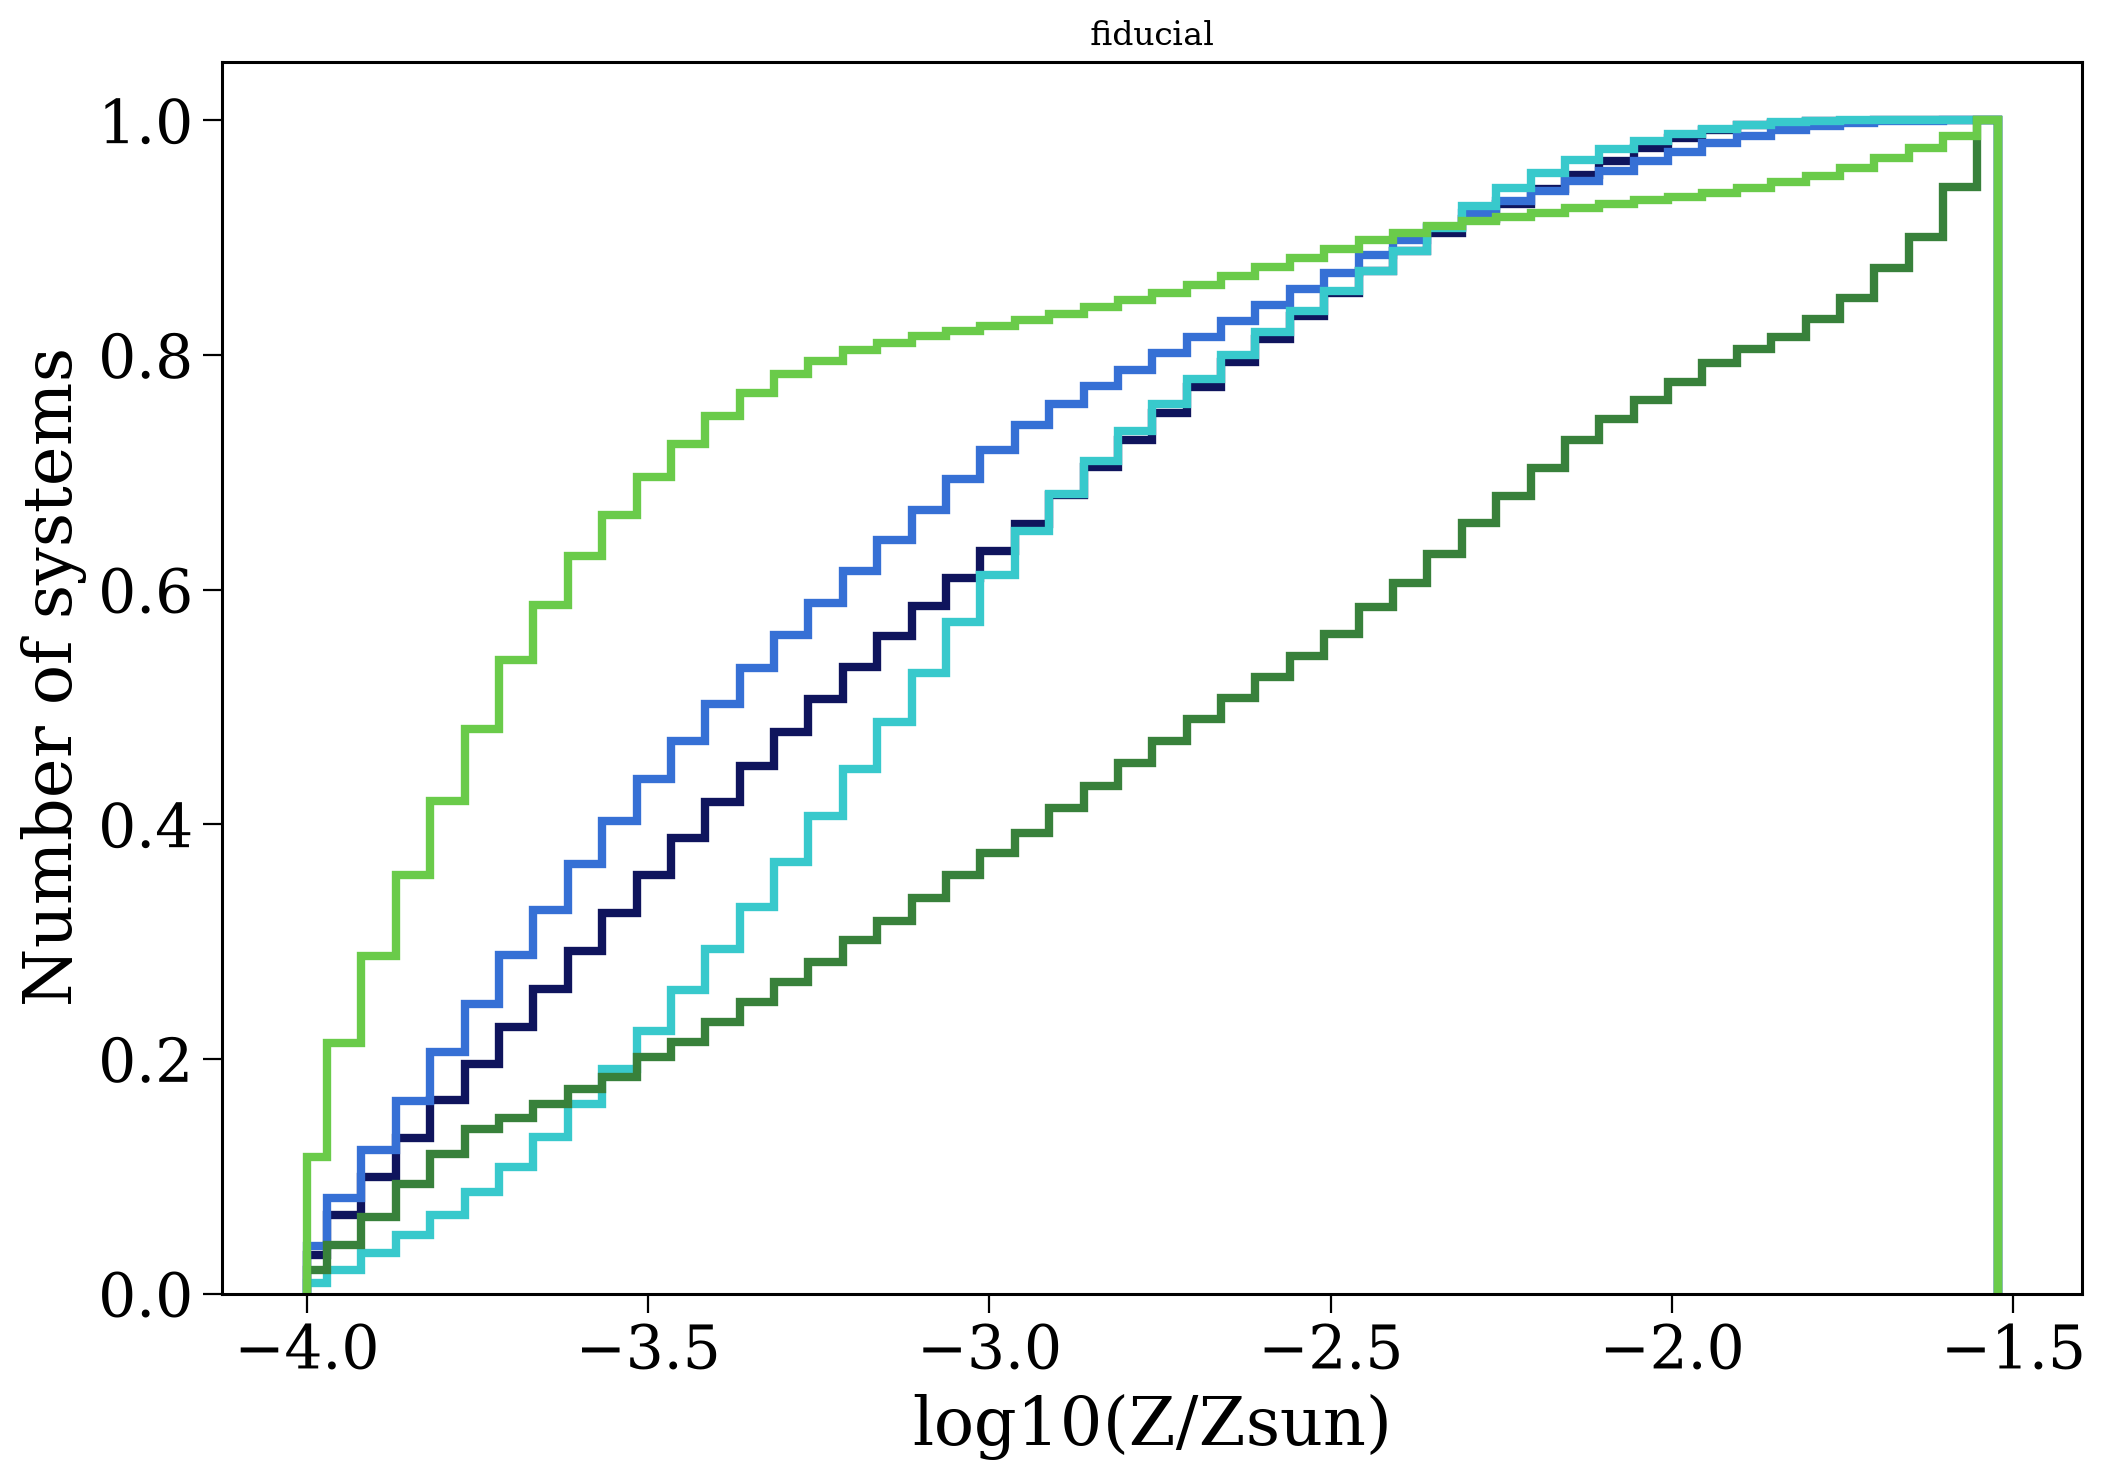

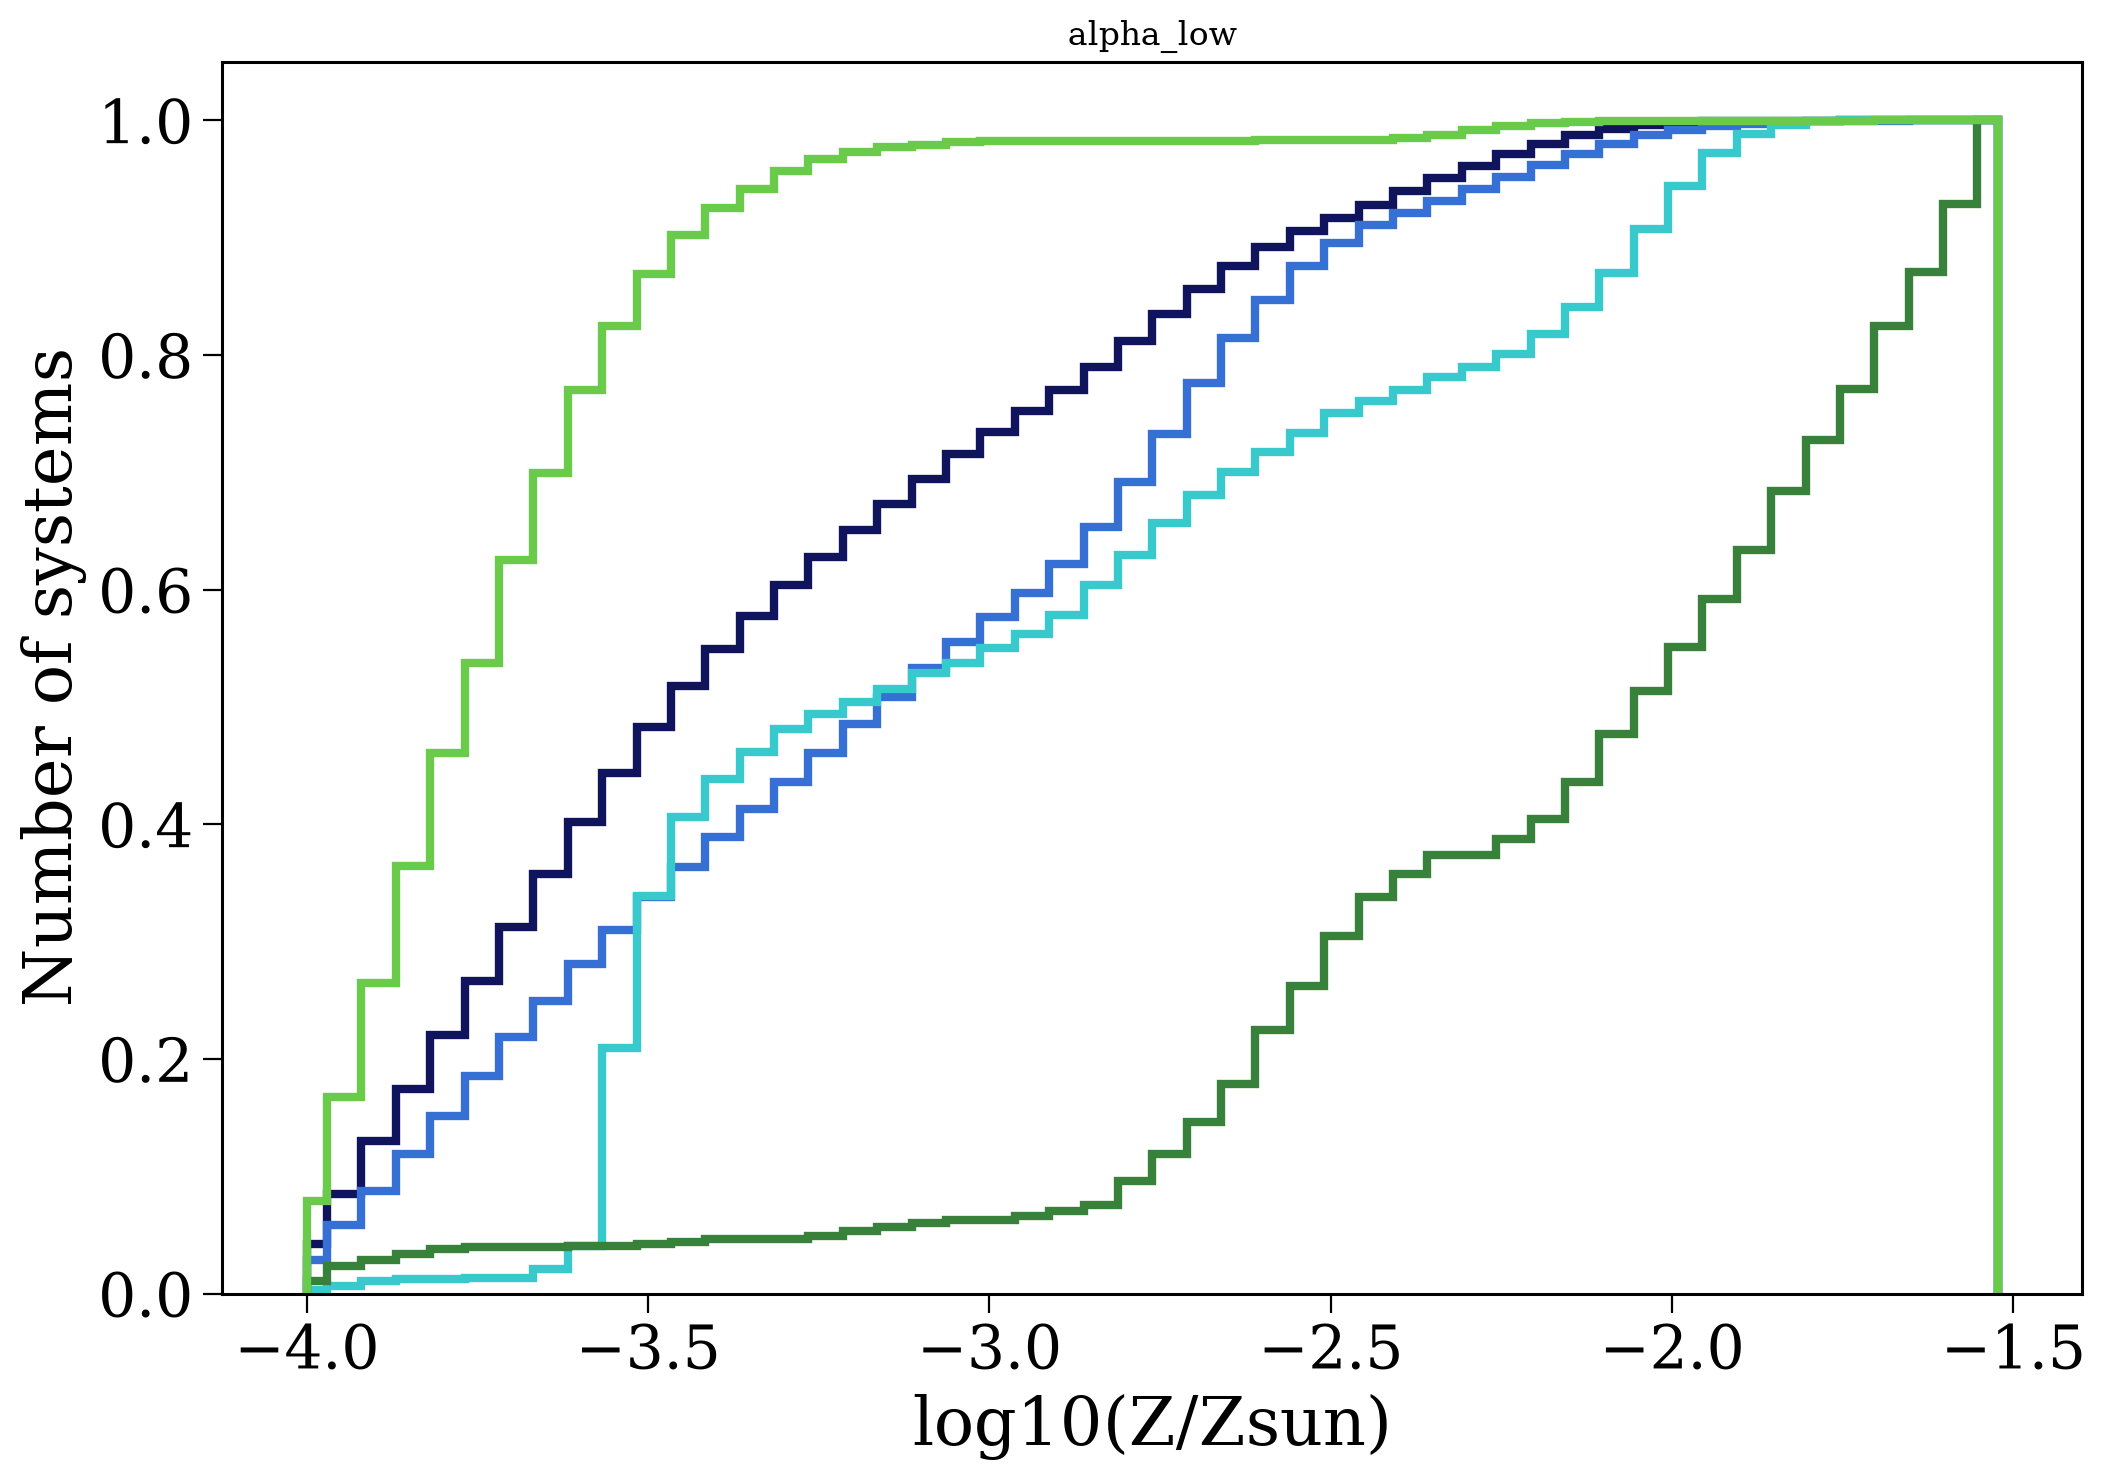

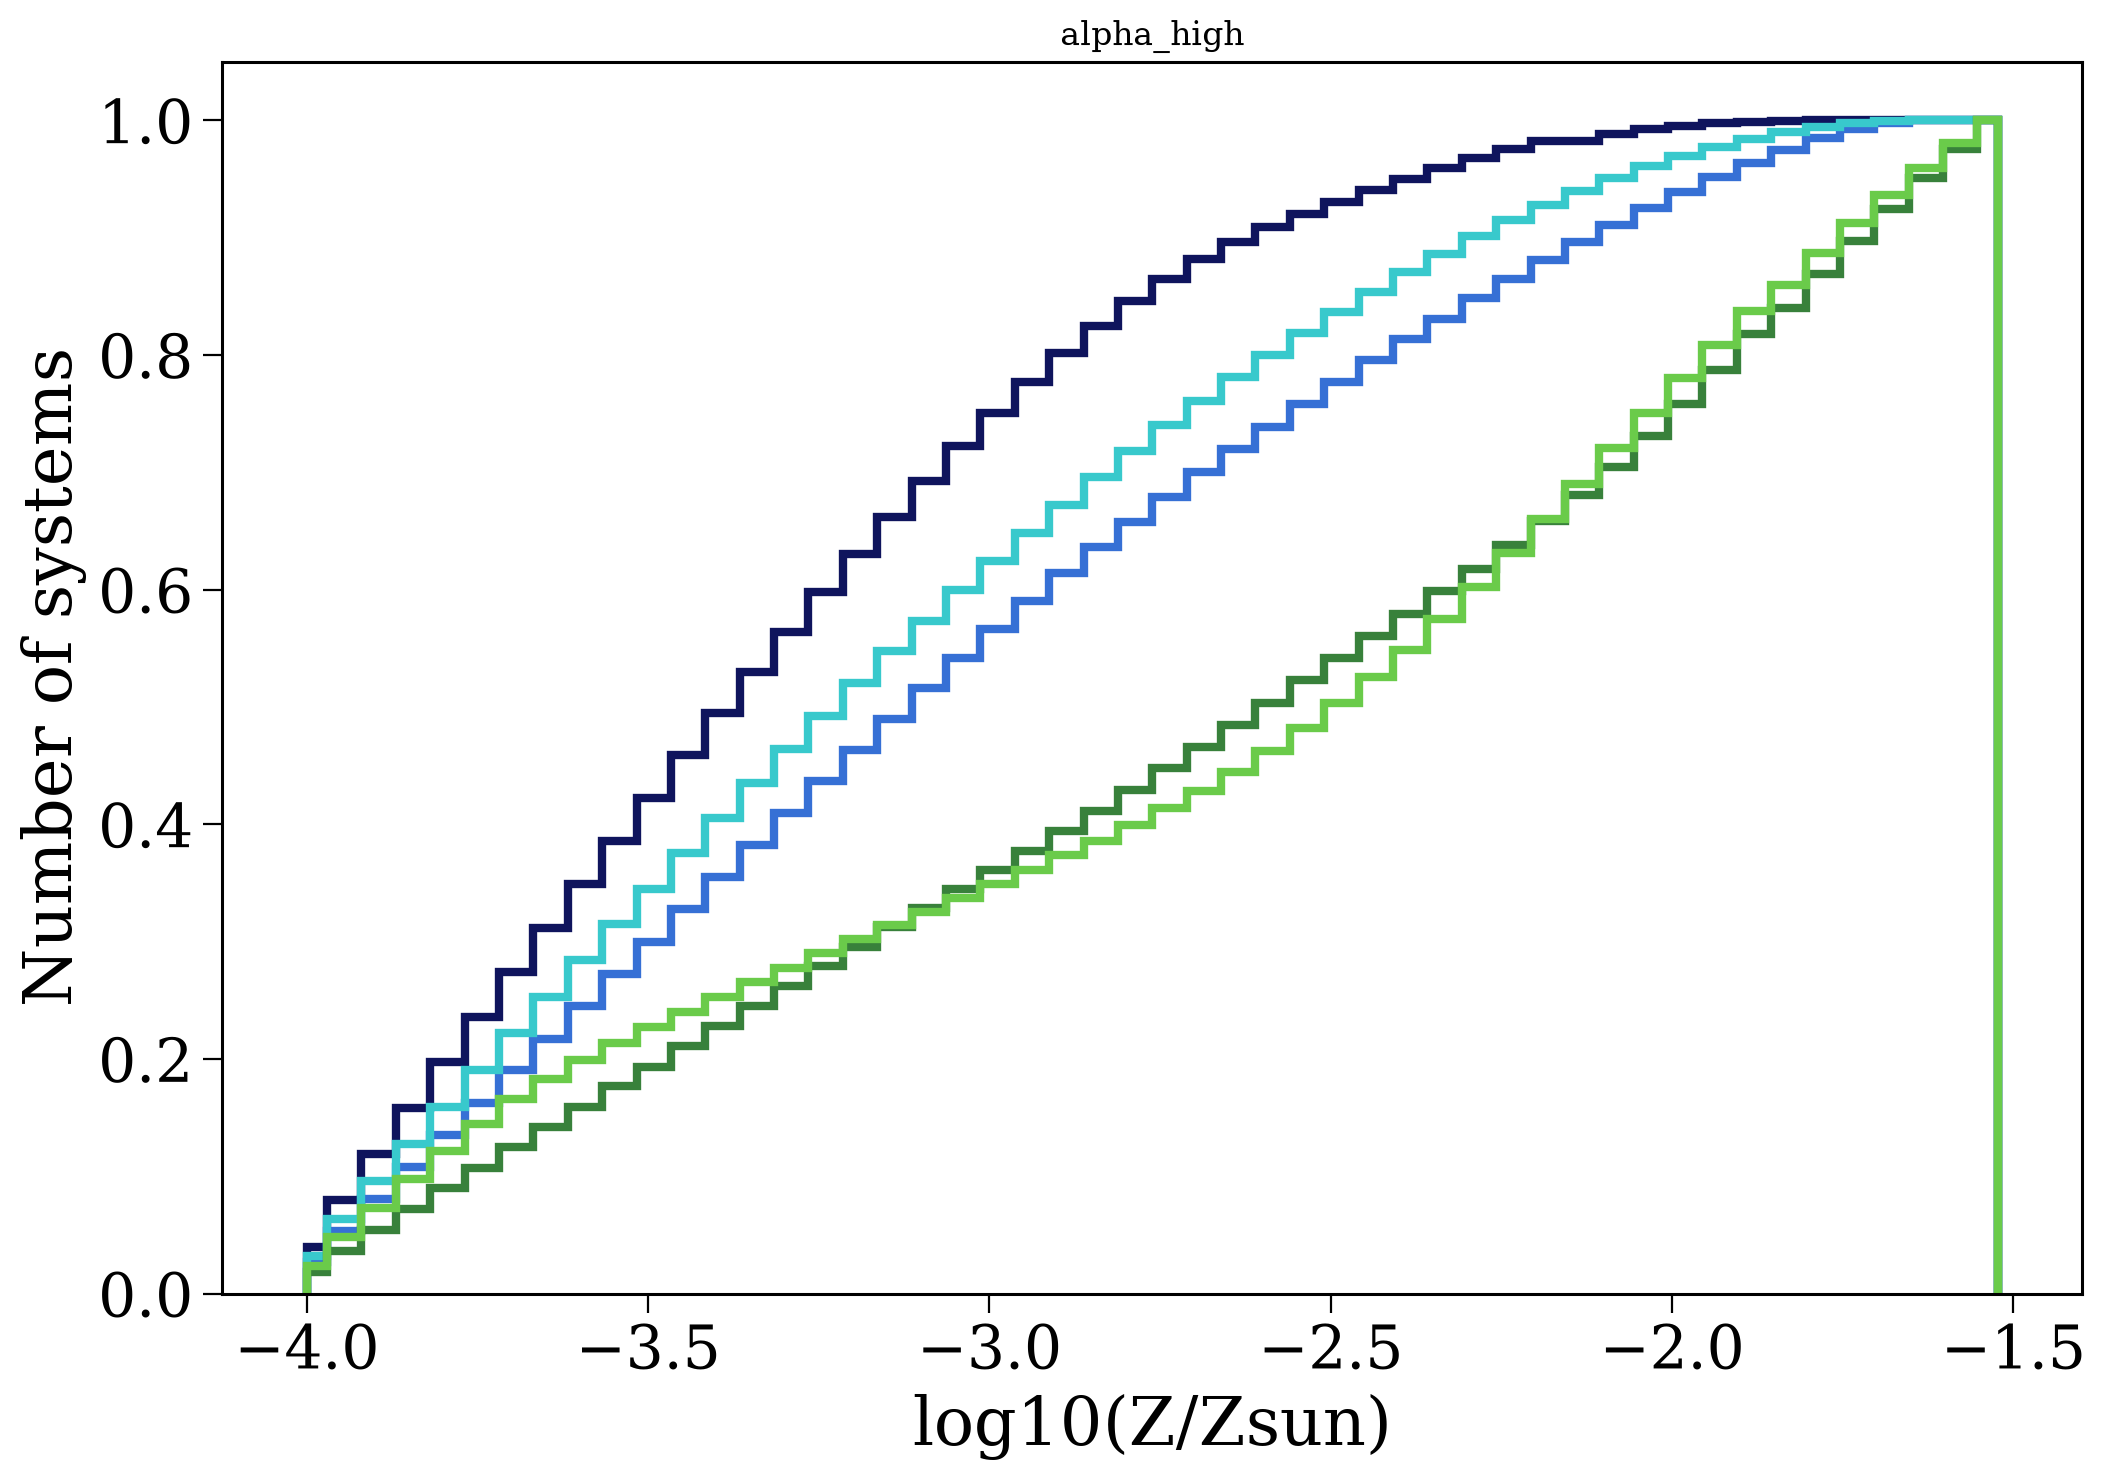

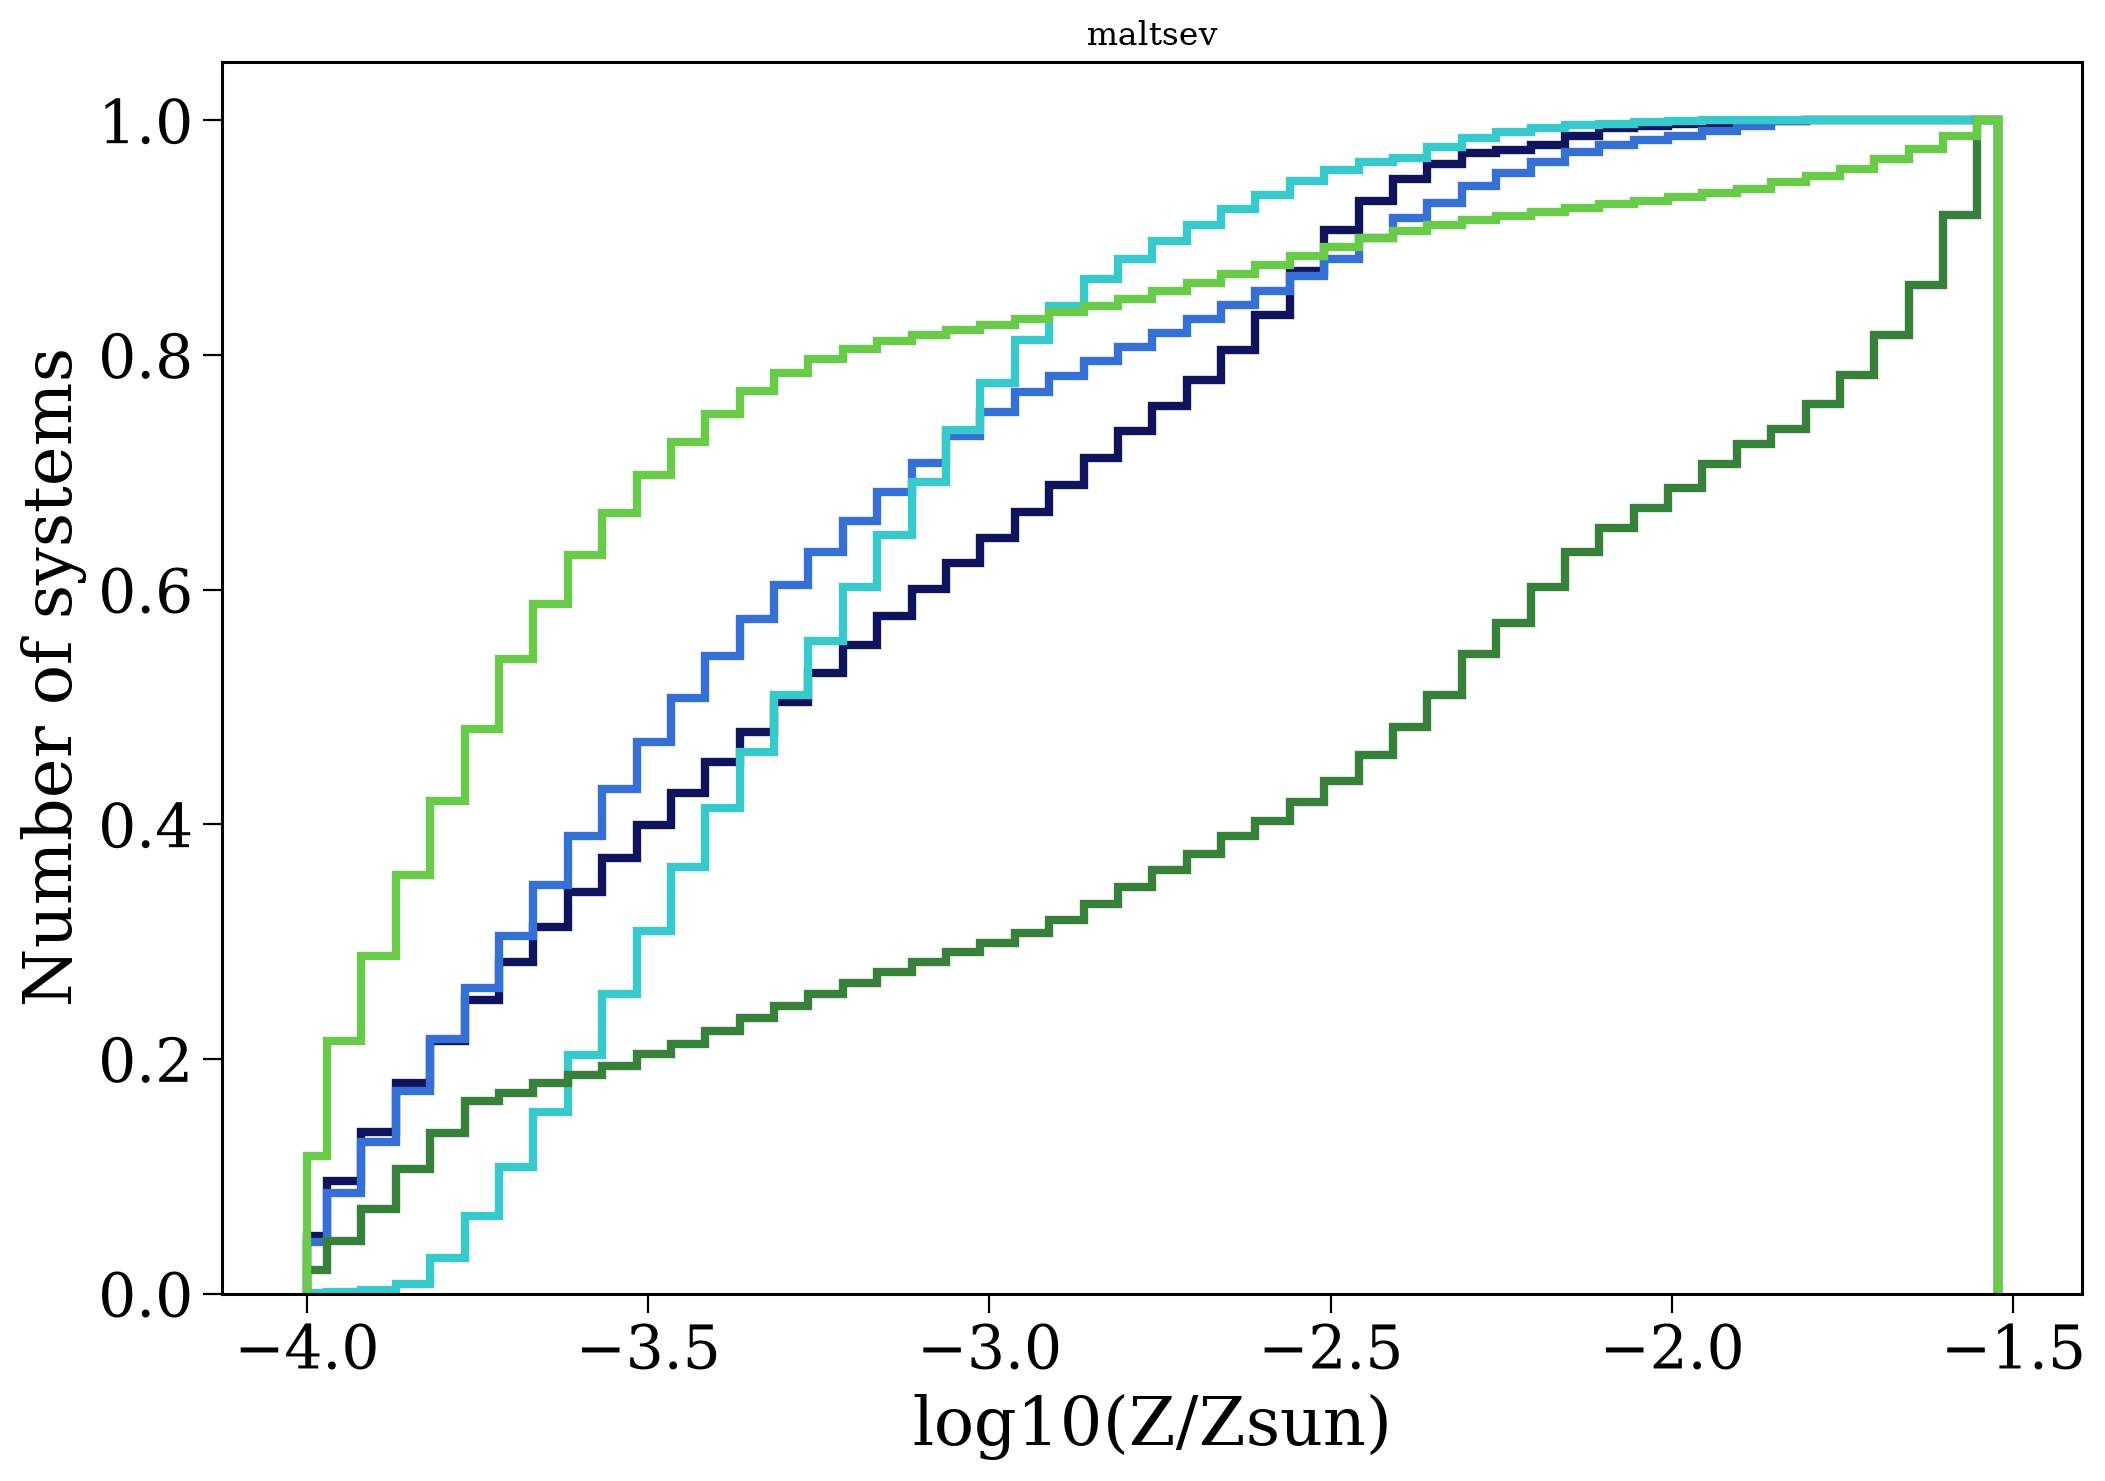

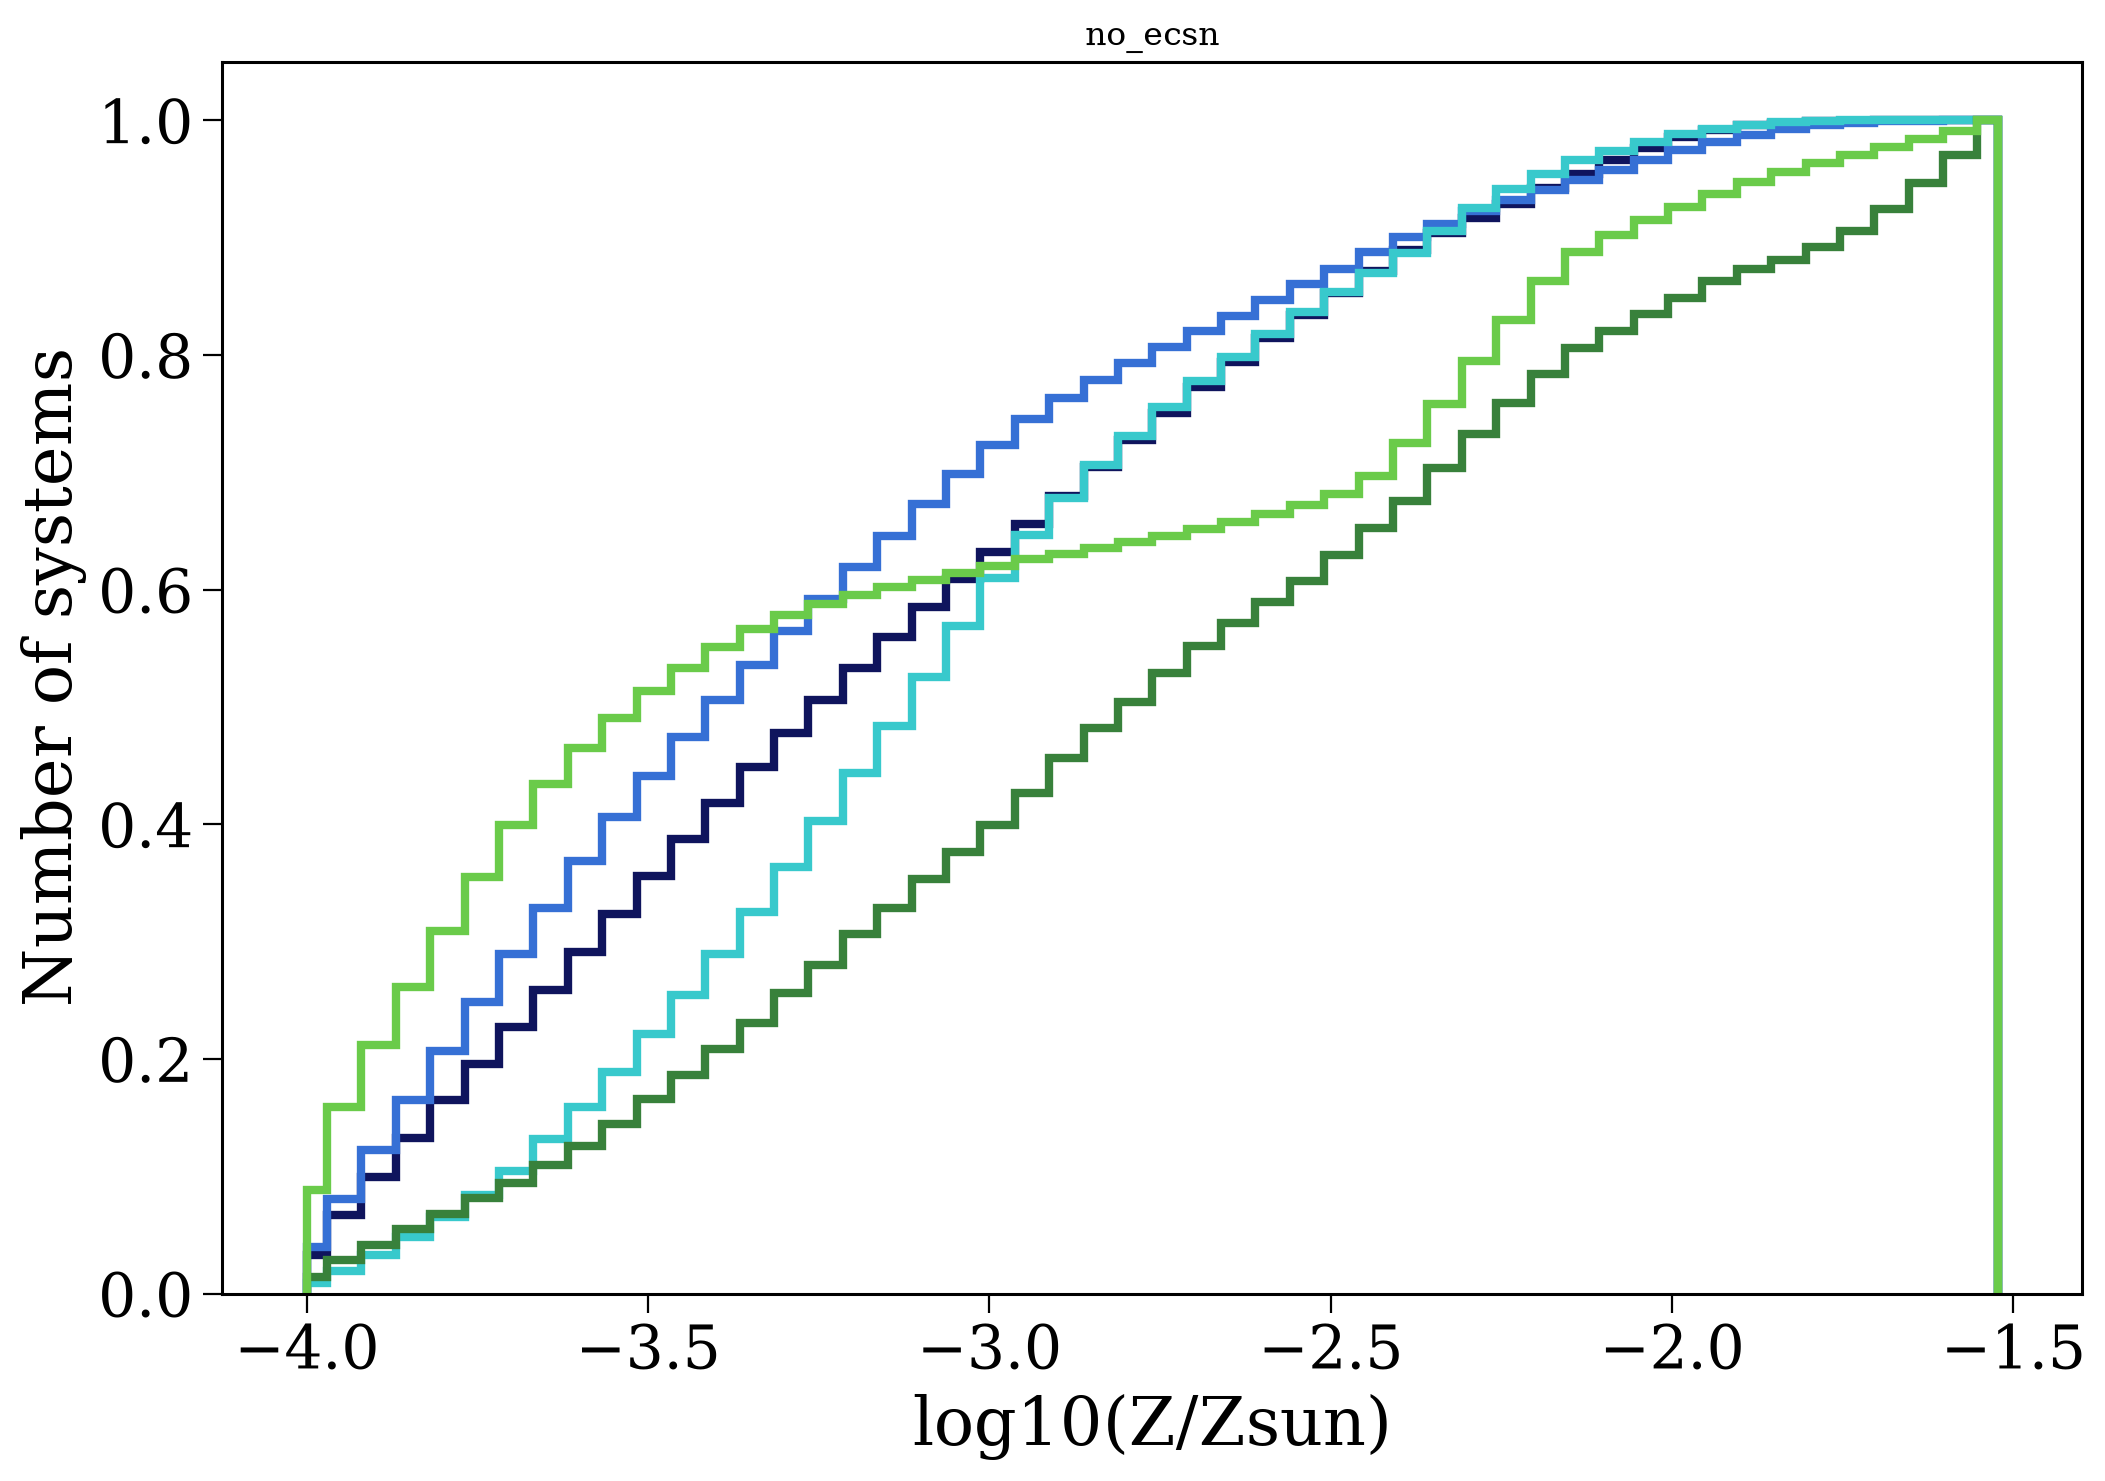

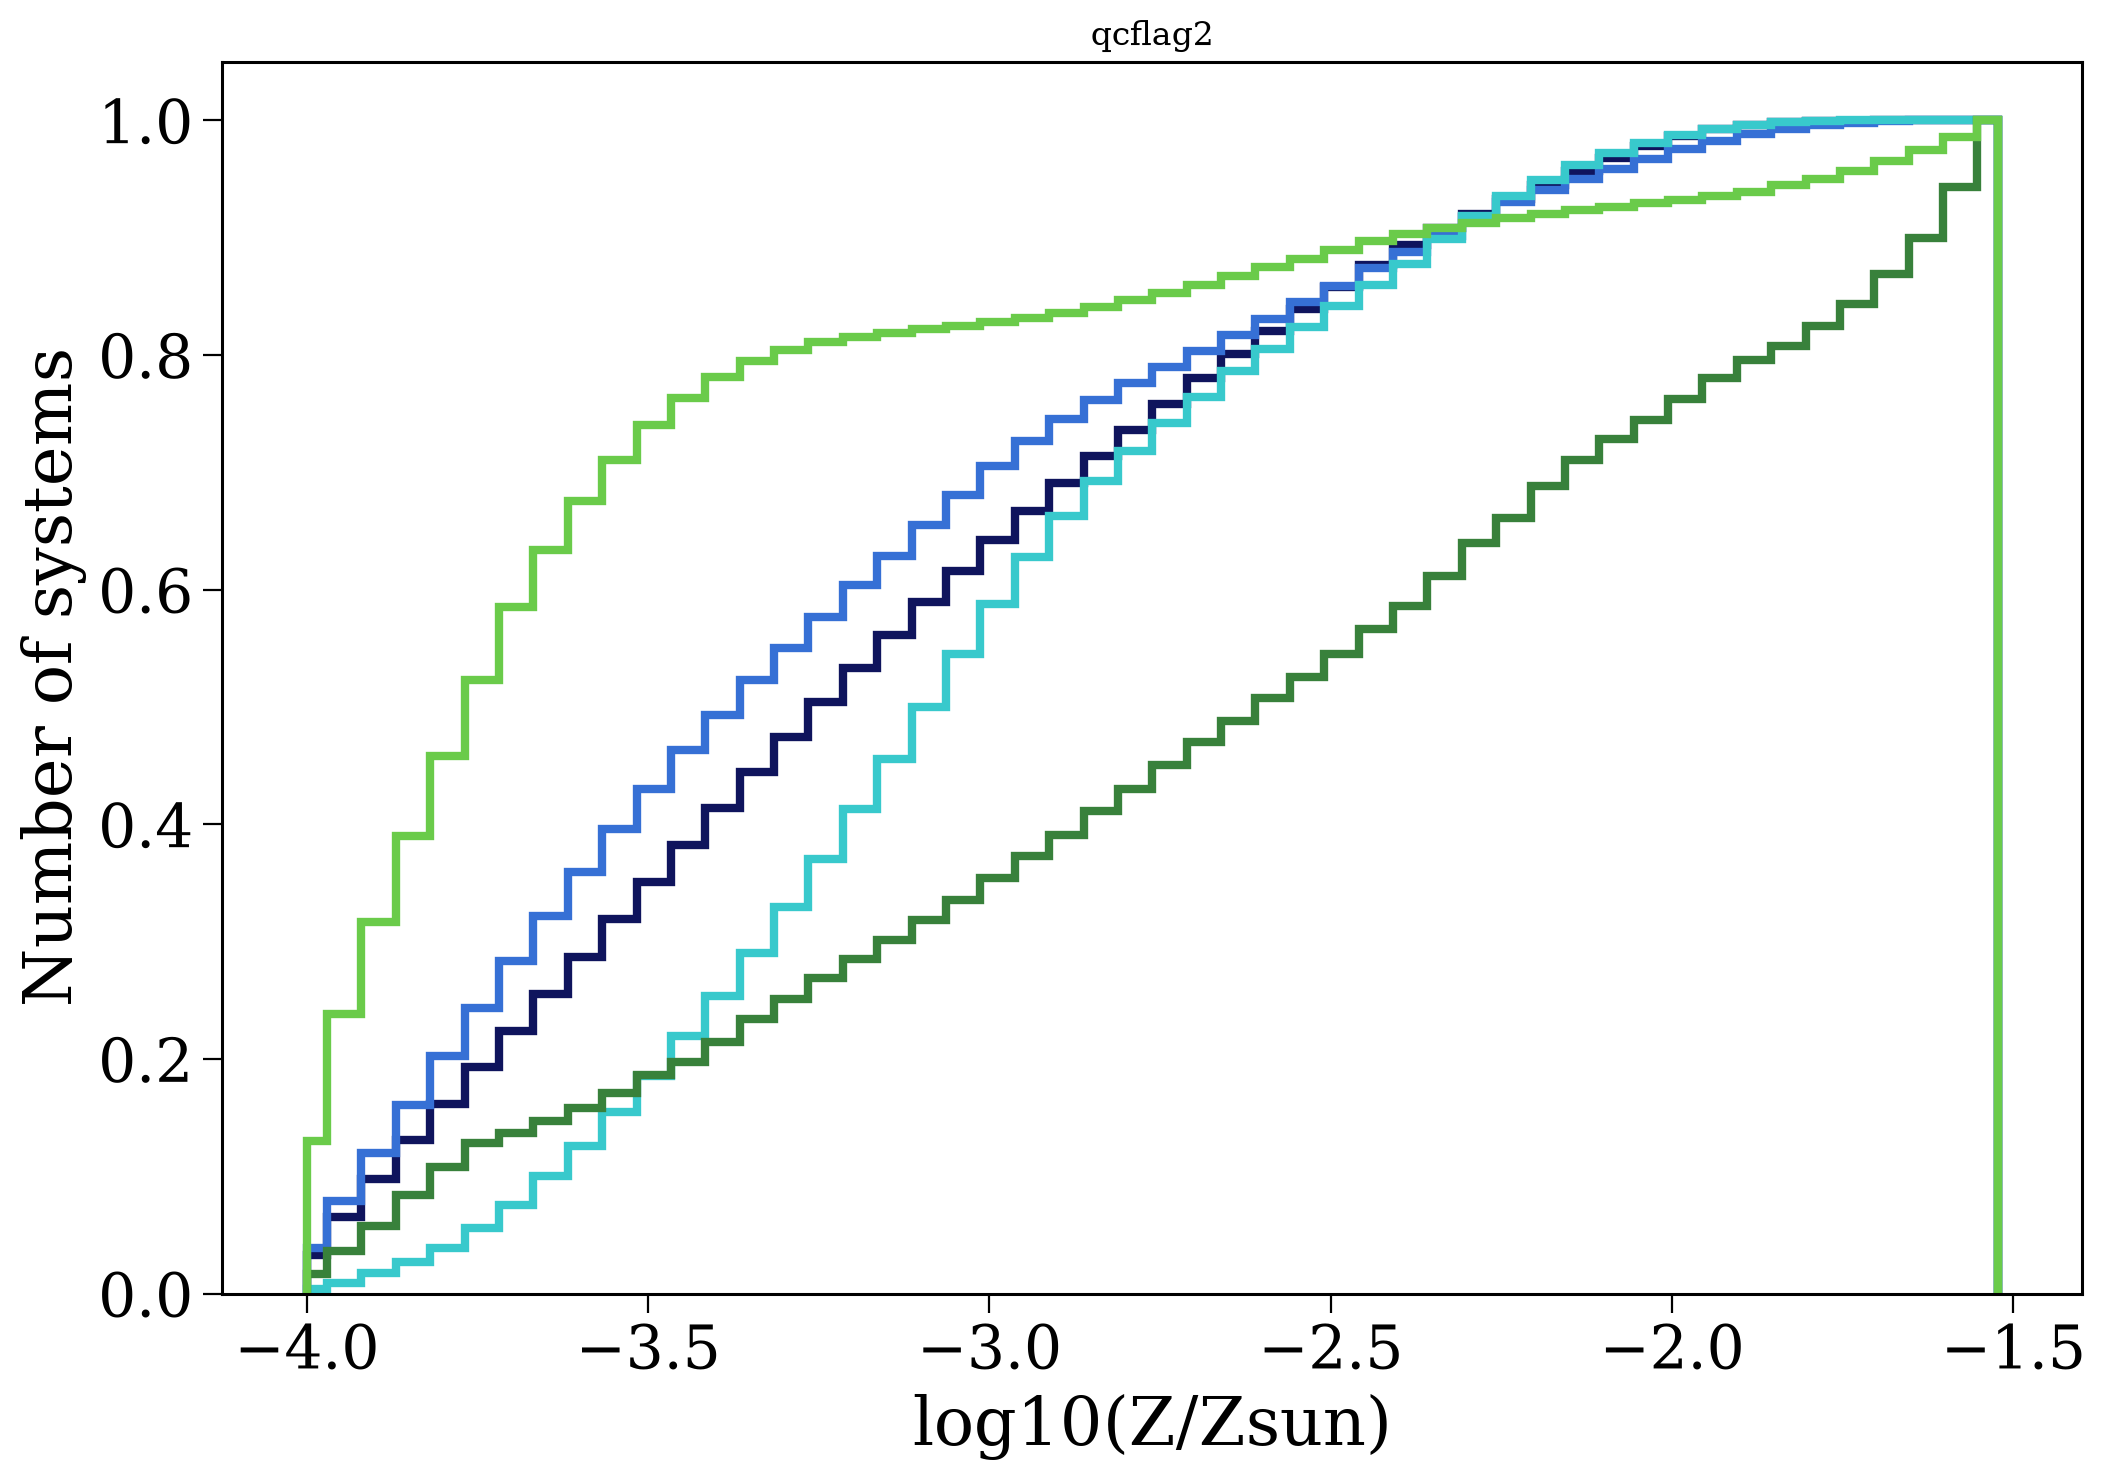

In [5]:

for v in const.VARIATIONS:
    fig, ax = plt.subplots()
    for dco in const.DCO_TYPES:
        ax.hist(np.log10(initCs[v][dco]["metallicity"]), bins=np.log10(const.Z_BIN_EDGES), histtype="step", color=const.DCO_COLOURS[dco], label=dco, density=True, lw=3, cumulative=True)
    ax.set_xlabel("log10(Z/Zsun)")
    ax.set_ylabel("Number of systems")
    ax.set_title(v)
    plt.show()

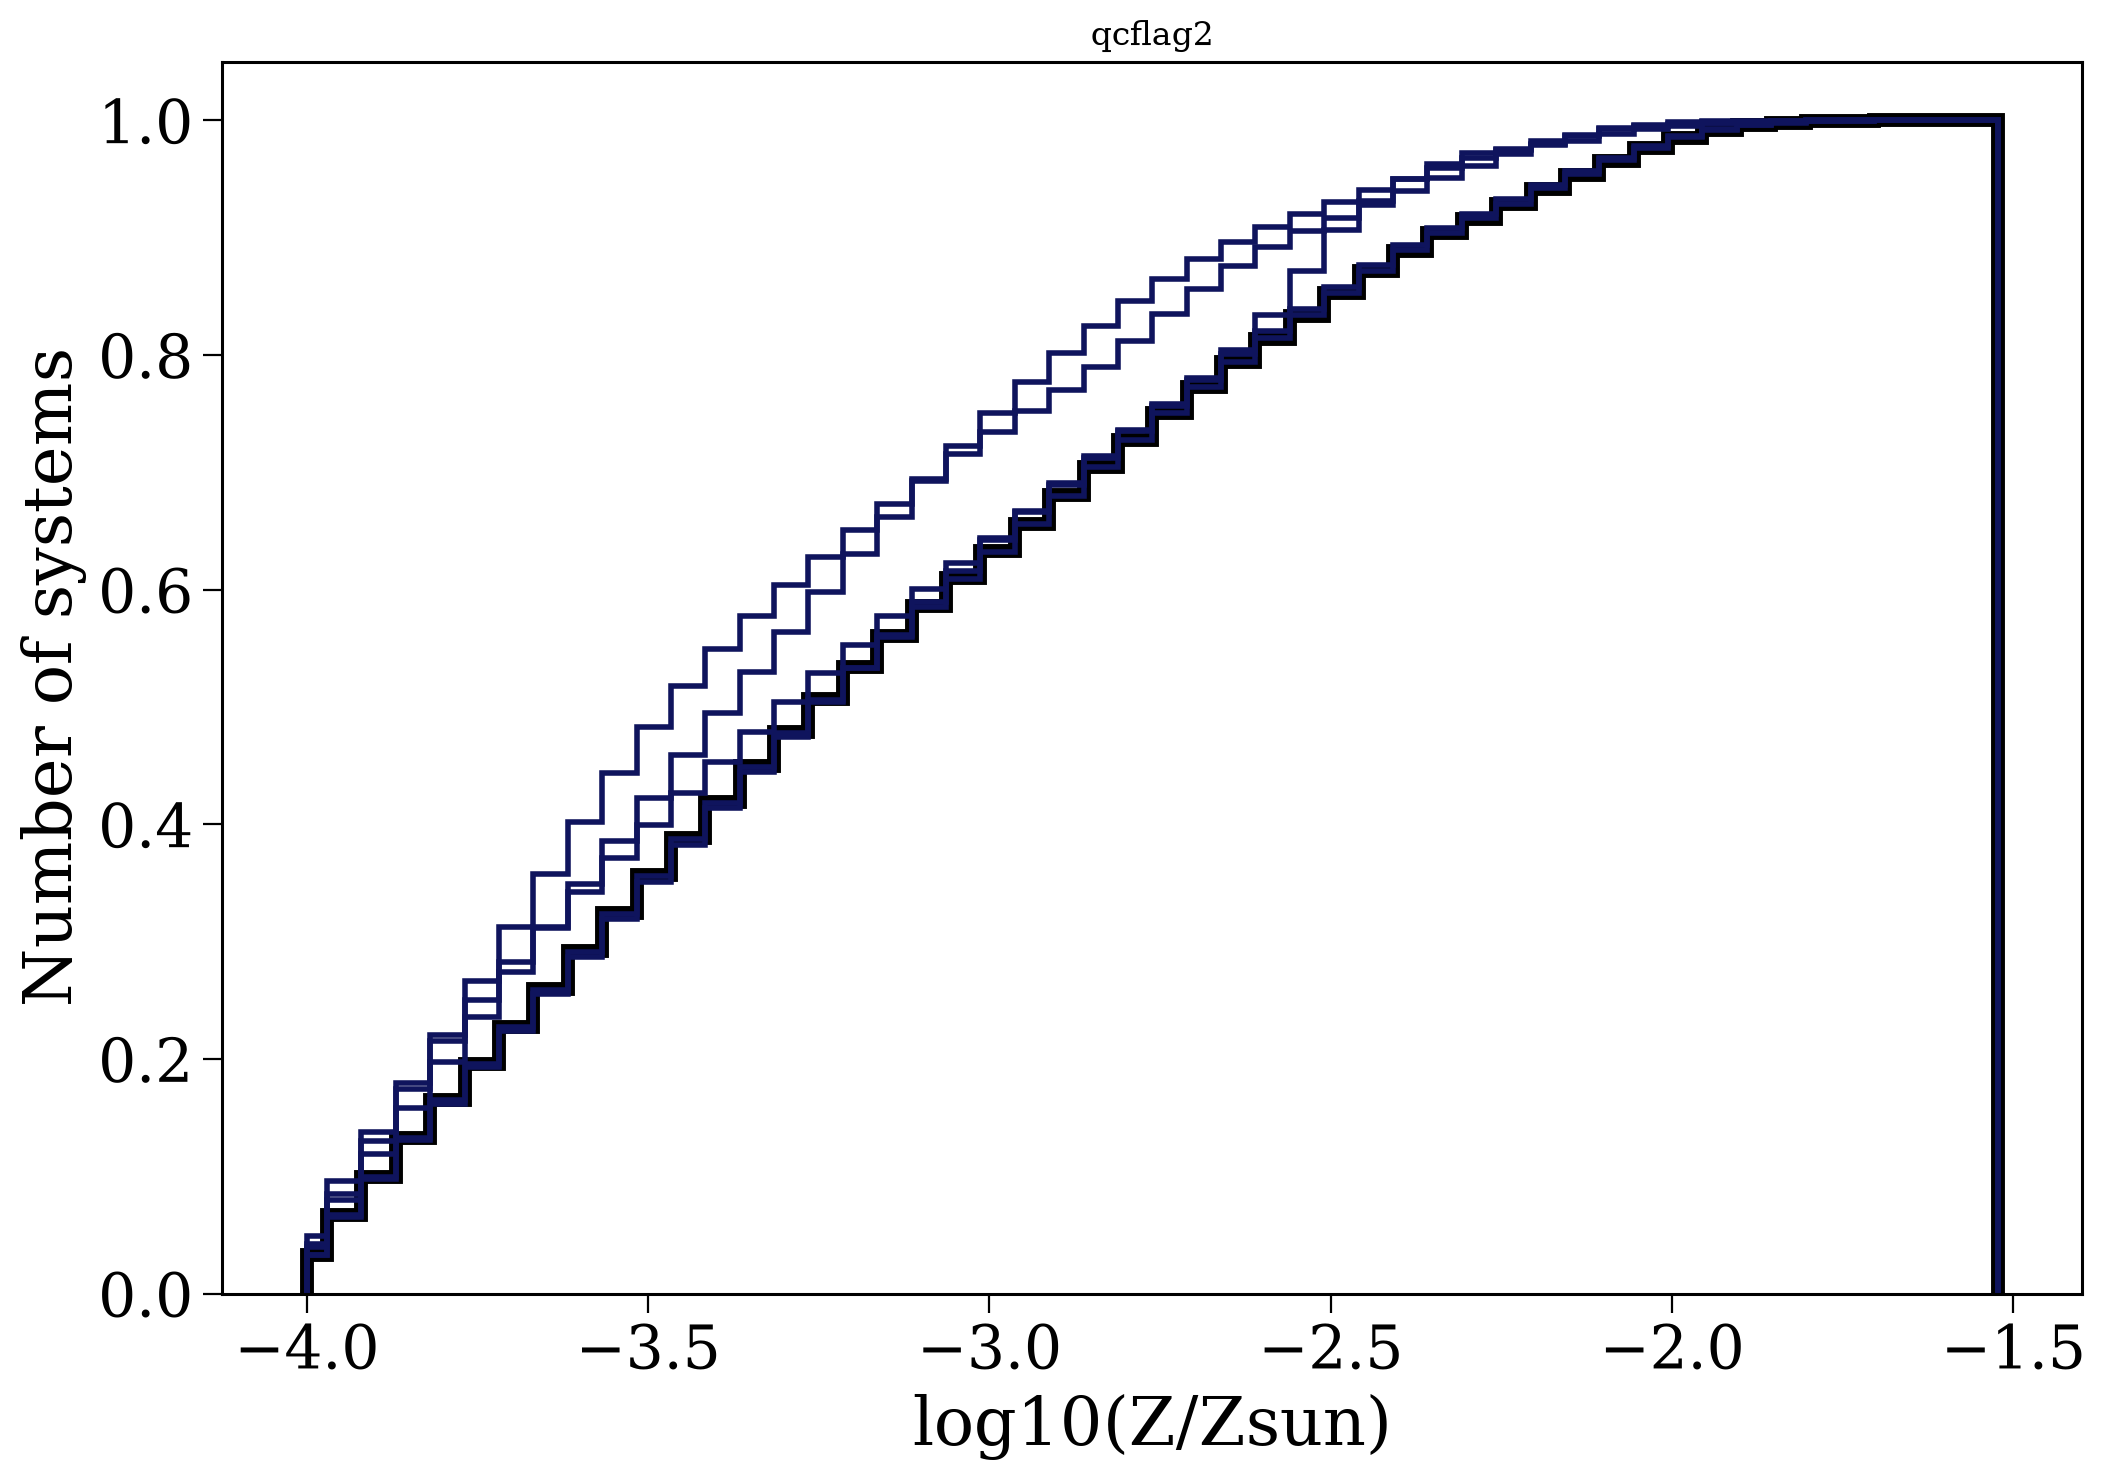

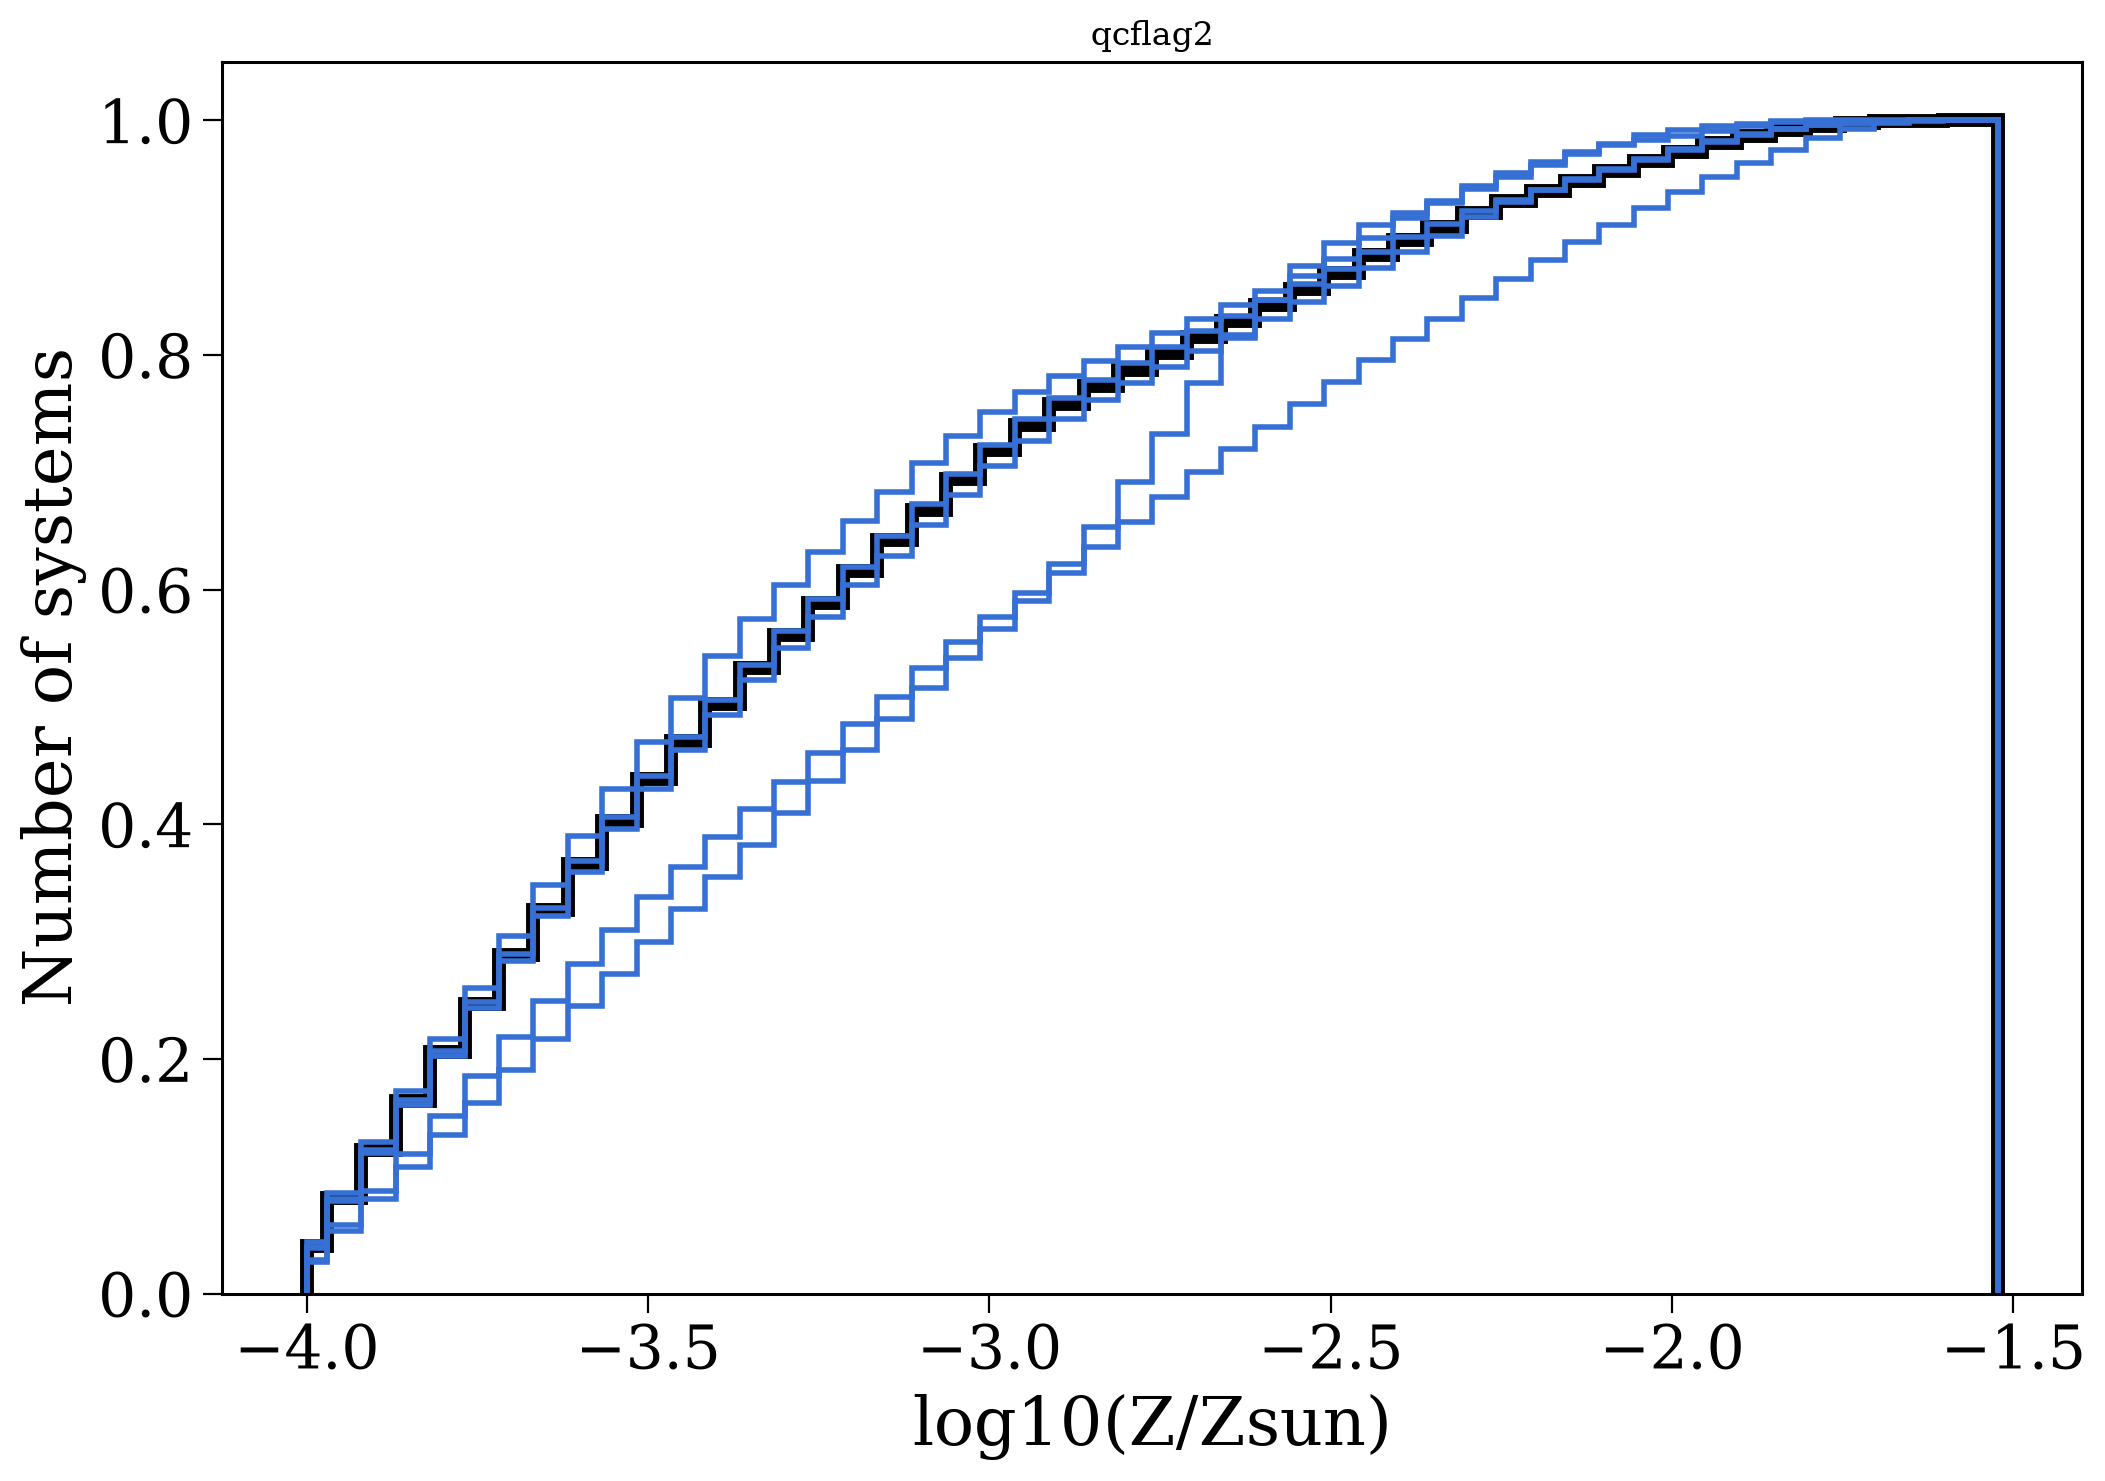

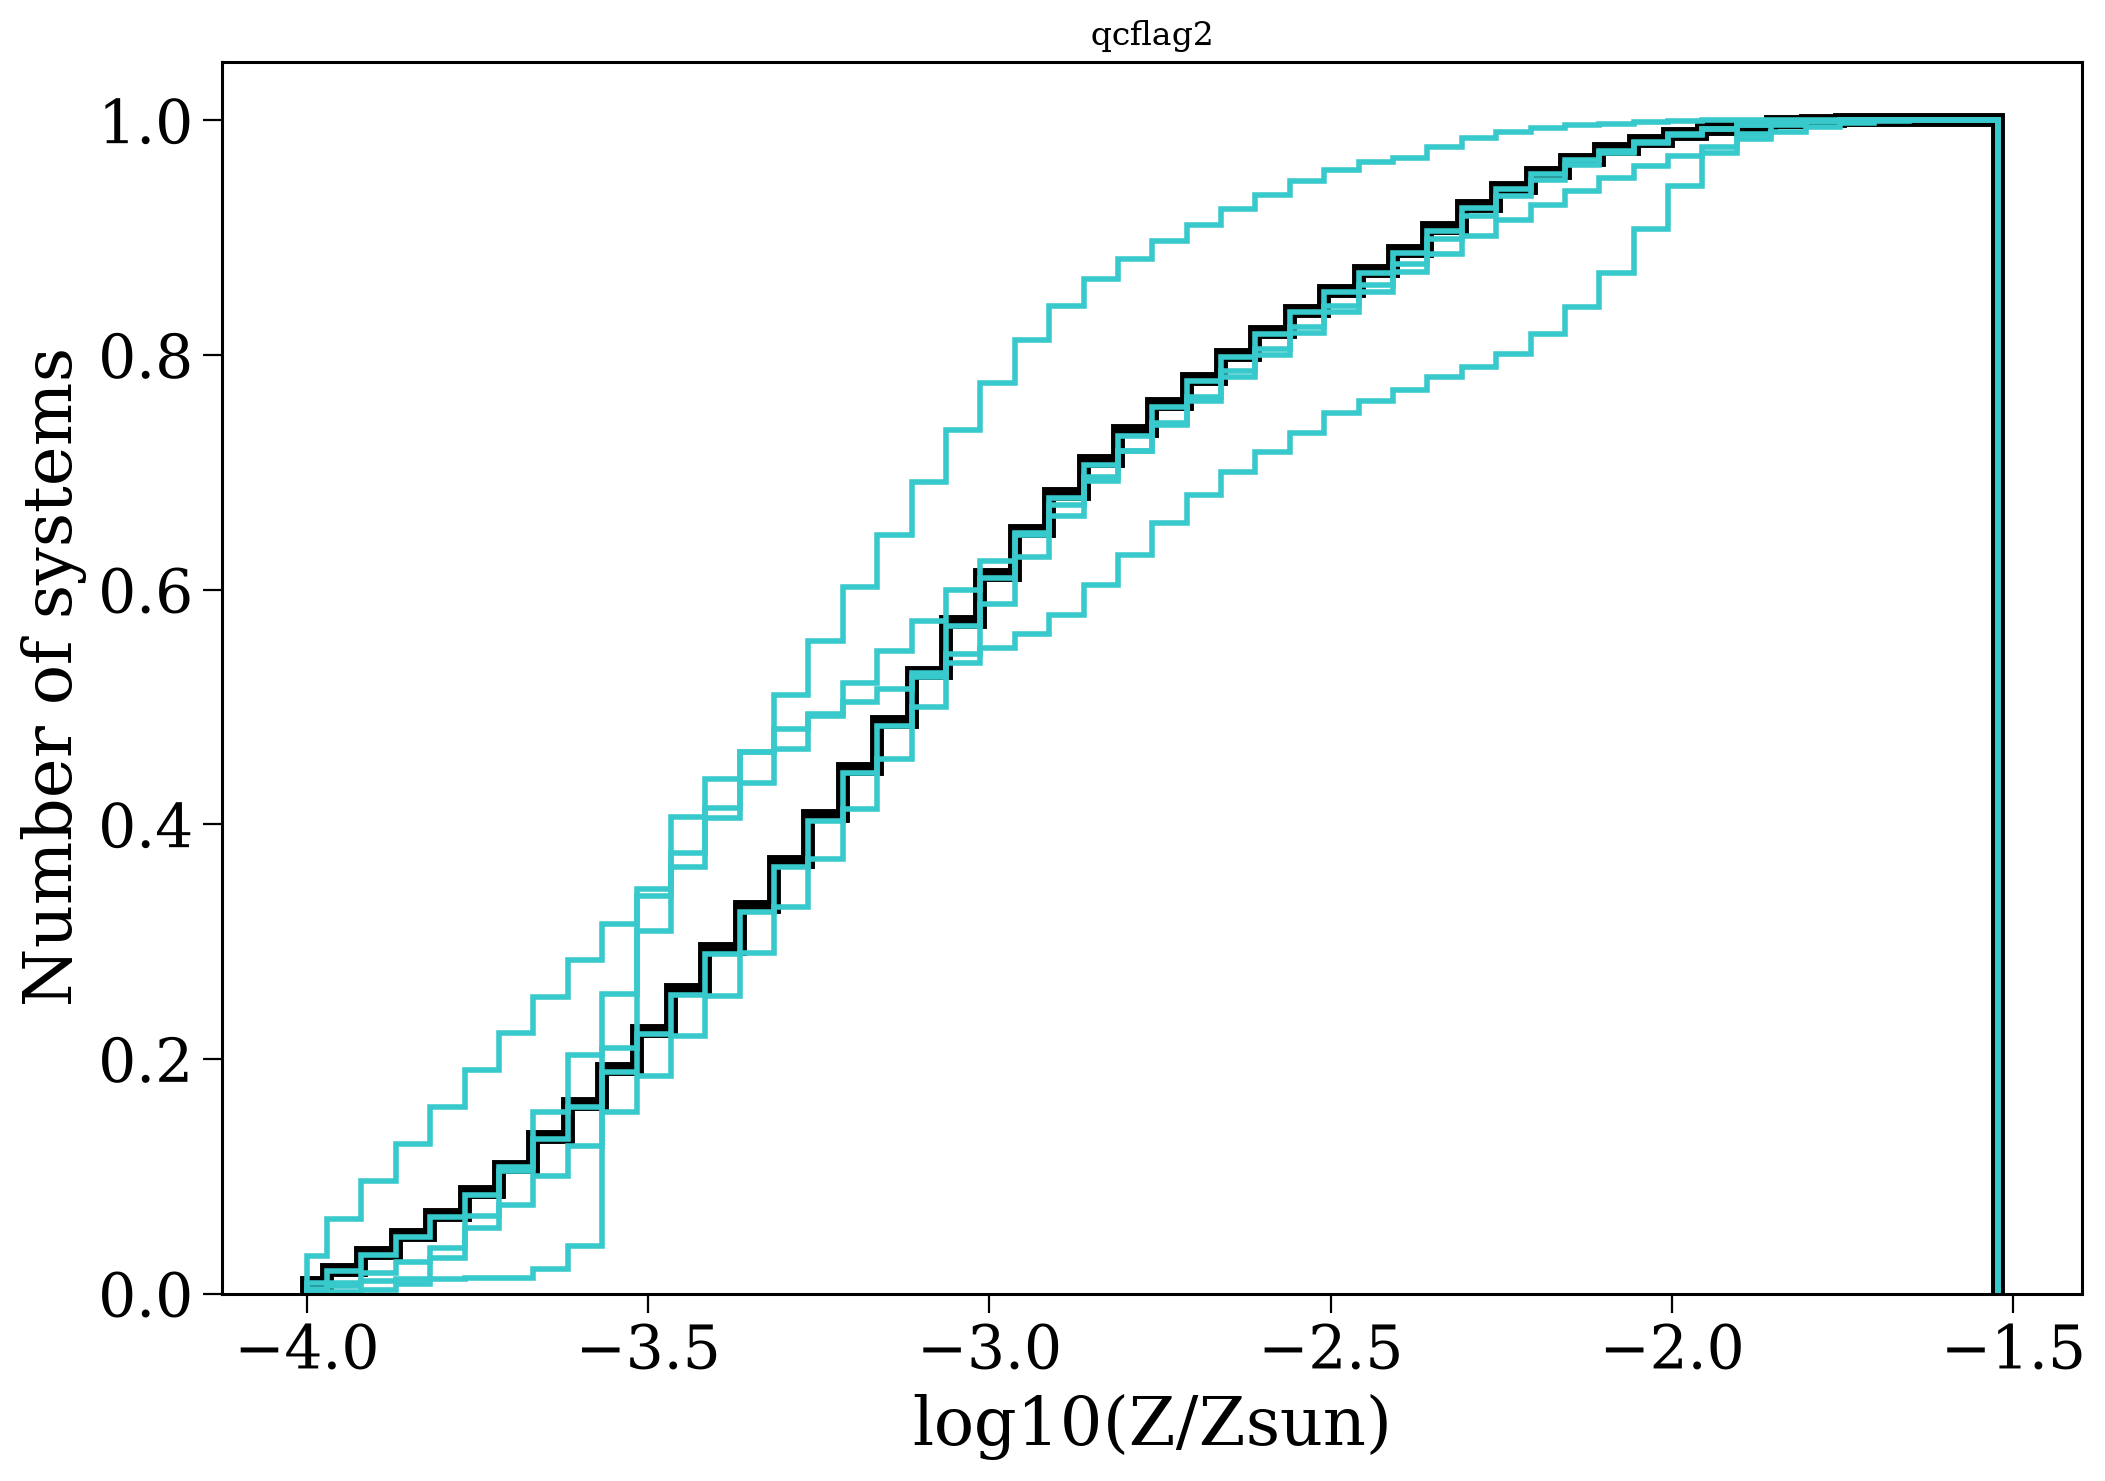

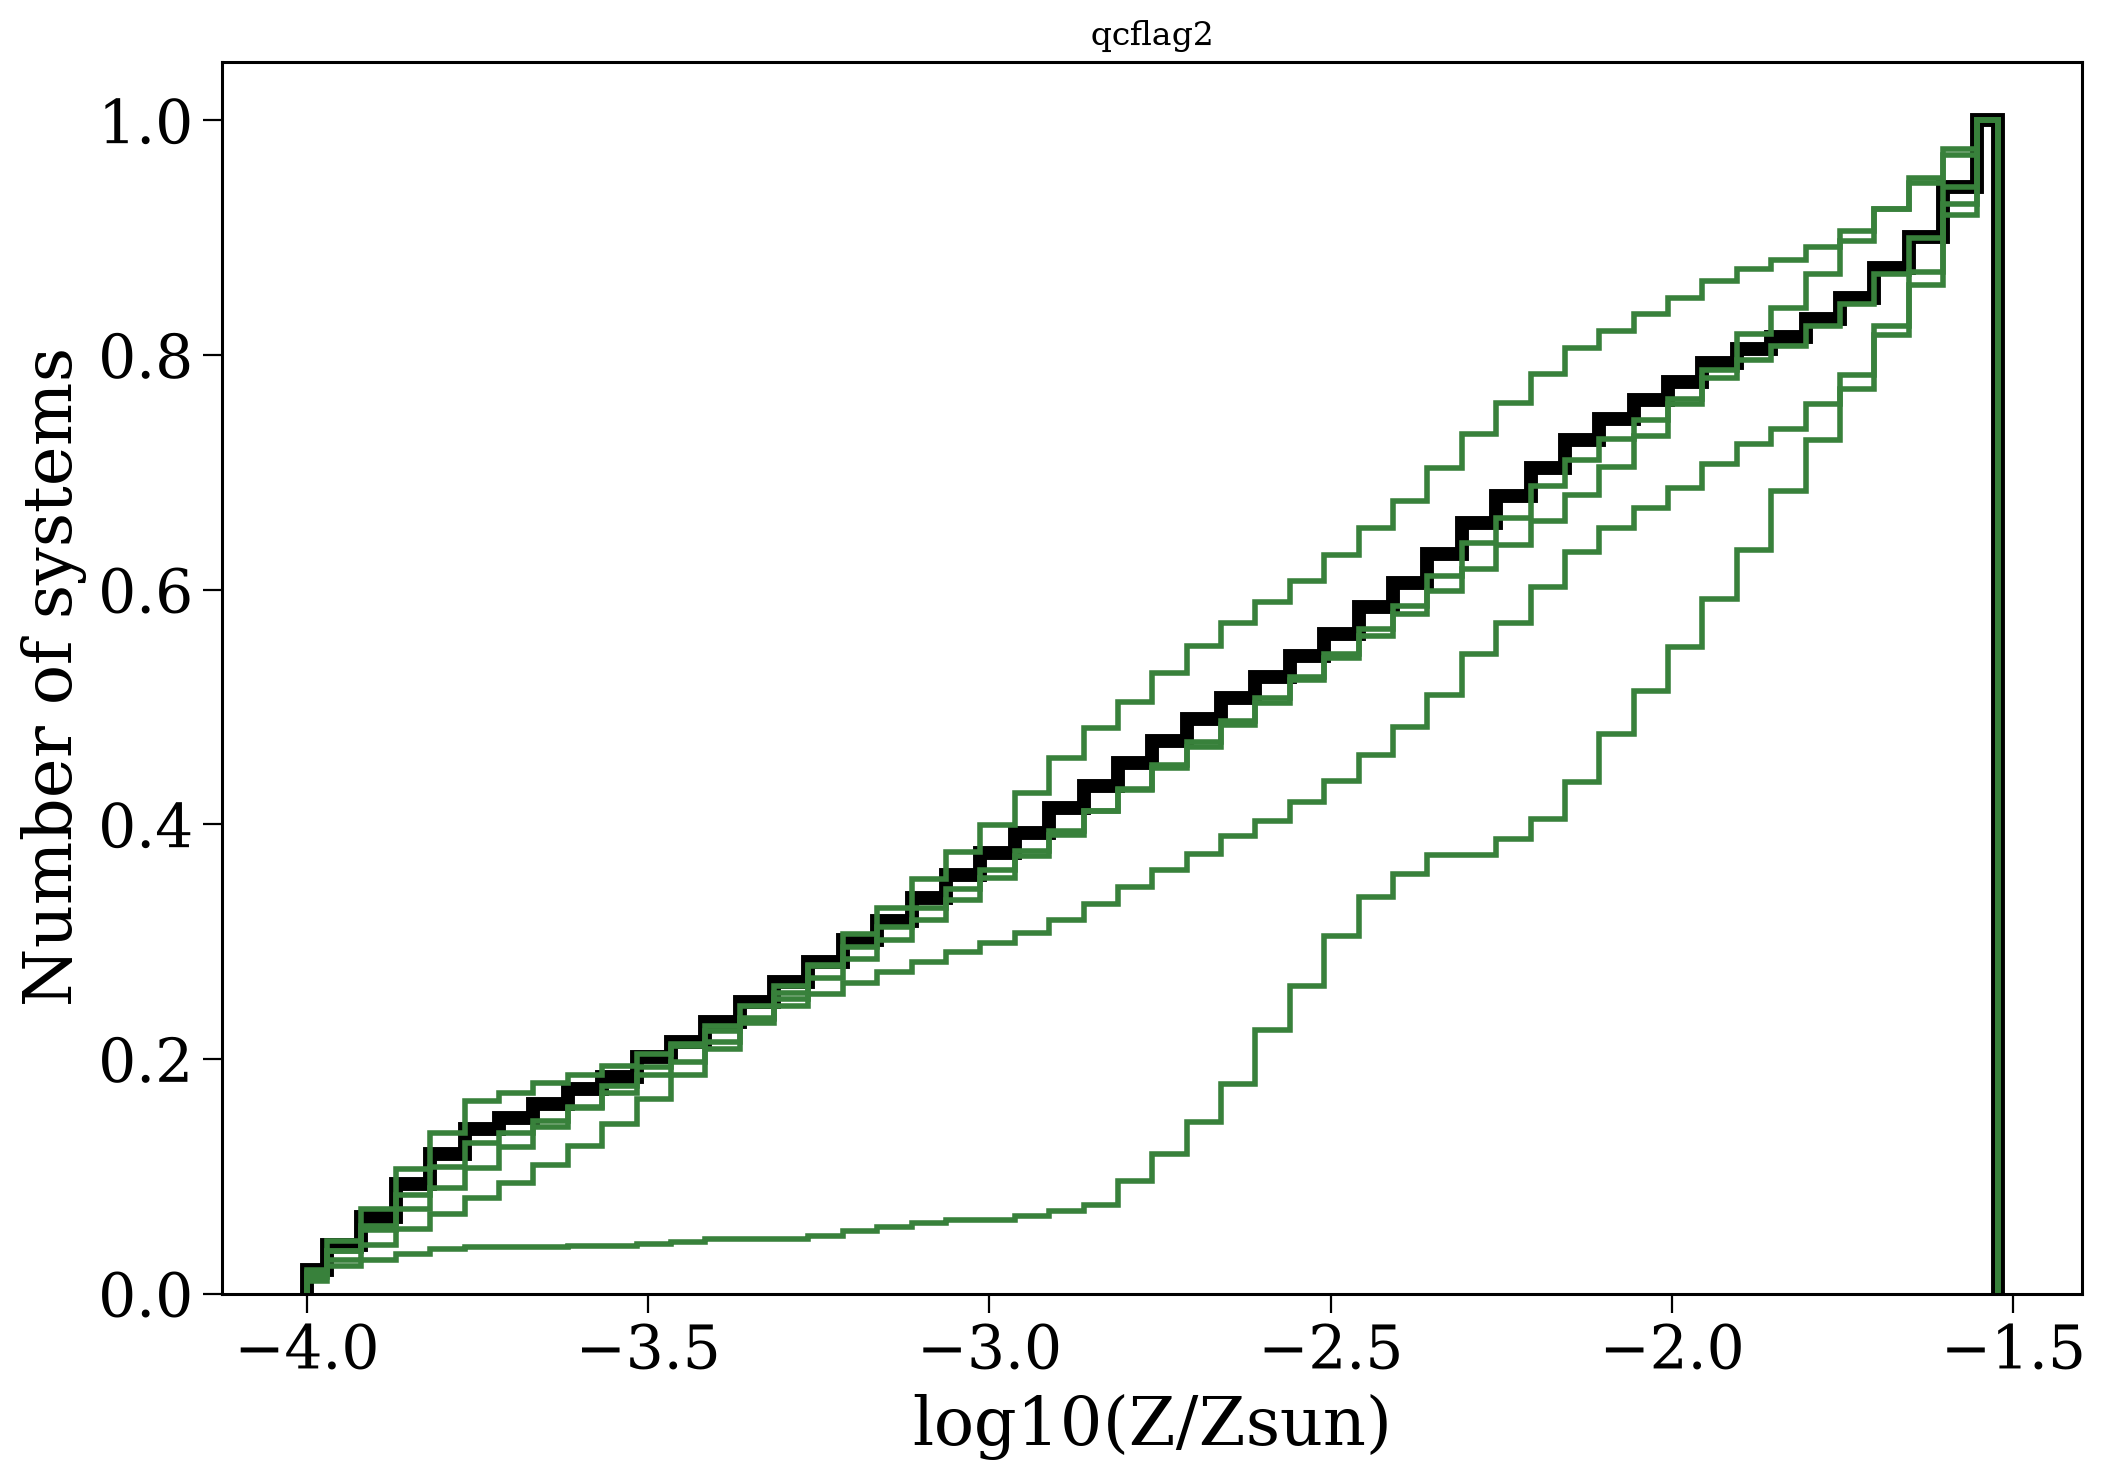

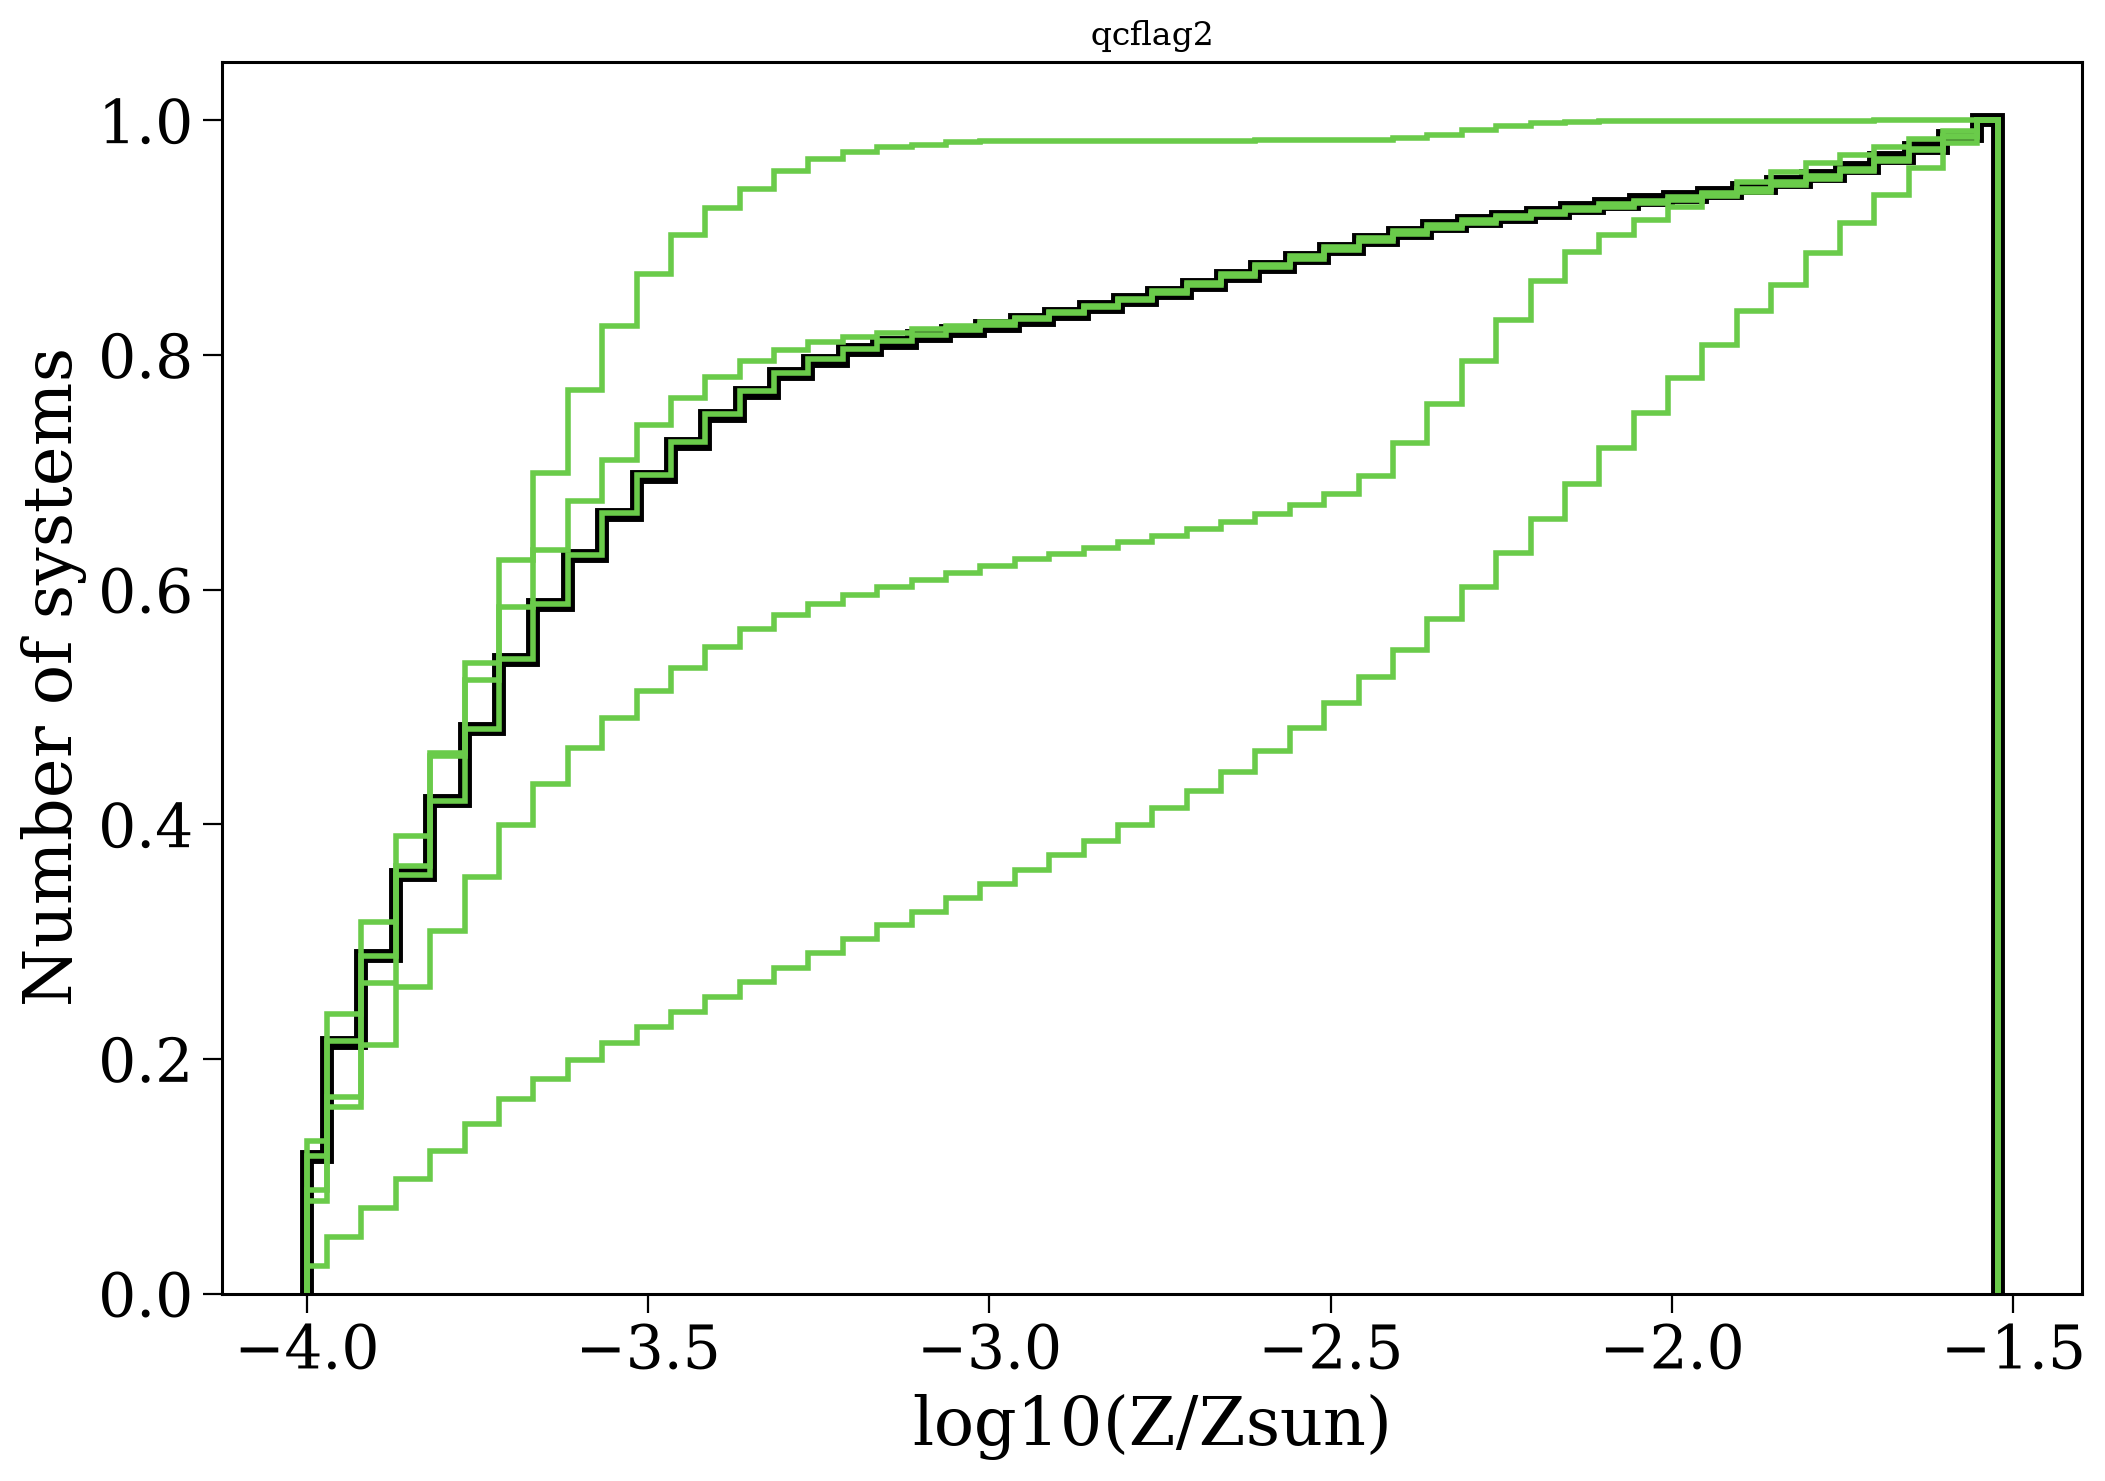

In [49]:

for dco in const.DCO_TYPES:
    fig, ax = plt.subplots()
    for v in const.VARIATIONS:
        ax.hist(np.log10(initCs[v][dco]["metallicity"]), bins=np.log10(const.Z_BIN_EDGES), histtype="step",
                color=const.DCO_COLOURS[dco] if v != "fiducial" else "black", label=dco, density=True, lw=5 if v == "fiducial" else 2, cumulative=True)
    ax.set_xlabel("log10(Z/Zsun)")
    ax.set_ylabel("Number of systems")
    ax.set_title(v)
    plt.show()

In [25]:
class SB15_PhiCut(cogsworth.sfh.SandersBinney2015):
    def __init__(self, phi_cut, *args, **kwargs):
            self.phi_cut = phi_cut
            super().__init__(*args, **kwargs)

    def _generate_df(self, J, component, tau):
        """Generate a distribution function for a given component and lookback time

        Follows `Sanders & Binney 2015 <https://ui.adsabs.harvard.edu/abs/2015MNRAS.449.3479S/abstract>`_
        Eq. 3.1.

        Parameters
        ----------
        J : `array-like`, shape (N, 3)
            Actions in (J_r, J_phi, J_z) in units of kpc^2 / Myr
        component : `str`
            Either "thin_disc" or "thick_disc"
        tau : :class:`~astropy.units.Quantity` [time]
            Lookback time

        Returns
        -------
        df_val : `array-like`, shape (N,)
            Value of the distribution function at the given actions
        """
        assert component in ["thin_disc", "thick_disc"], "Component must be 'thin_disc' or 'thick_disc'"

        J_r, J_z, J_phi = J.T

        # only compute the DF where the prior interpolations are valid
        df_val = np.full_like(J_r, np.nan)
        valid = (J_phi >= 1e-5) & (J_phi <= 100)

        R_d = 3.45 if component == "thin_disc" else 2.31
        L_0 = 0.01

        # get guiding radii
        R_g = np.zeros_like(J_r)
        R_g[valid] = self._guiding_radius_interp(J_phi[valid])
        valid &= (R_g >= 1e-2) & (R_g <= 100)
        R_g = R_g[valid]

        # get frequencies at guiding radii based on potential
        omega = self._omega_interp(R_g)
        kappa = self._kappa_interp(R_g)
        nu = self._nu_interp(R_g)

        # time dependent velocity dispersions
        kms_to_kpcMyr = (u.km / u.s).to(u.kpc / u.Myr)
        sigma_R = self._get_sigma_i("R", R_g, tau, component) * kms_to_kpcMyr
        sigma_z = self._get_sigma_i("z", R_g, tau, component) * kms_to_kpcMyr

        # construct DF
        prefactor = 1 / (8 * np.pi**3) * (1 + np.tanh(J_phi[valid] / L_0))          # no units
        exp_terms = [
            omega / (R_d**2 * kappa**2) * np.exp(-R_g / R_d),                       # units of Myr/kpc^2
            (kappa / sigma_R**2) * np.exp(-kappa * J_r[valid] / sigma_R**2),        # units of Myr/kpc^2
            (nu / sigma_z**2) * np.exp(-nu * J_z[valid] / sigma_z**2)               # units of Myr/kpc^2
        ]
        df_val[valid] = prefactor * np.prod(exp_terms, axis=0)                      # units of Myr^3/kpc^6

        df_val[(J_phi < self.phi_cut)] = 0.0

        return df_val

In [59]:
WEIGHTS_PATH = "/mnt/home/twagg/projects/frank-lisa/data/MW_Z_weights.npy"
if os.path.isfile(WEIGHTS_PATH):
    MW_weights = np.load(WEIGHTS_PATH)

for v in const.VARIATIONS:
    for dco in const.DCO_TYPES:
        formation_rows[v][dco]["MW_Z_weight"] = 0.0
        for Z in const.Z_BIN_CENTRES:
            formation_rows[v][dco].loc[formation_rows[v][dco]["metallicity"] == Z, "MW_Z_weight"] = MW_weights[np.digitize(Z, const.Z_BIN_CENTRES) - 1]

In [65]:
counts < target_counts

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False])

In [64]:
target_counts

array([  105,   240,   345,   361,   434,   521,   588,   760,   928,
        1157,  1295,  1605,  1869,  2146,  2613,  3150,  3577,  4279,
        4956,  5603,  6656,  8159, 10242, 12135, 13688, 16119, 18152,
       19994, 22112, 24400, 26803, 29089, 29844, 27245, 24900, 25525,
       26753, 26944, 24948, 23000, 18397, 13136,  7784,  4298,  1983,
         856,   229,    69,     8,     0])

In [62]:
np.argmax(counts < target_counts)

np.int64(0)

np.float64(0.0267)

In [84]:
with h5.File(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/NSWD_at_formation.h5", "r") as f:
    print(f["formation_rows"].keys())

<KeysViewHDF5 ['axis0', 'axis1', 'block0_items', 'block0_values', 'block1_items', 'block1_values', 'block2_items', 'block2_values']>


In [81]:
import time

v = "fiducial"
dco = "BHBH"
n_per_instance = 500_000
oversample_factor = 4

lap = time.time()

# draw a random sample, weighted by the Milky Way metallicity distribution
rand_sample = formation_rows[v][dco].sample(n_per_instance, weights="MW_Z_weight", replace=True)


# work out the target number of systems in each metallicity bin, for galaxy sampling
target_counts, _ = np.histogram(rand_sample["metallicity"].values, bins=const.Z_BIN_EDGES)
sample_size = target_counts.sum() * oversample_factor

# loop variables
counts, rnd, sfhs = np.zeros_like(target_counts), 0, []

print(f"  [{time.time() - lap:03.1f}s] Starting to sample from the SFH to get {target_counts.sum()} systems in the right metallicity bins...")
lap = time.time()

# continue until we have enough systems in each metallicity bin
while np.sum(counts) < np.sum(target_counts):

    # find the maximum metallicity that doesn't have a full bin
    max_Z = const.Z_BIN_CENTRES[counts < target_counts].max()

    print("   ", max_Z)

    # max Z is below 1e-3 then switch to the phi cut version
    if max_Z <= 5e-4:
        print("    Using phi cut of 3.0 for max_Z <= 5e-4")
        SB15 = SB15_PhiCut(phi_cut=3.0, potential=gp.MilkyWayPotential(version="v2"))
    elif max_Z <= 1e-3:
        print("    Using phi cut of 2.0 for max_Z <= 1e-3")
        SB15 = SB15_PhiCut(phi_cut=2.0, potential=gp.MilkyWayPotential(version="v2"))
    else:
        print("    Using phi cut of 0.0 for max_Z > 1e-3")
        SB15 = SB15_PhiCut(phi_cut=0.0, potential=gp.MilkyWayPotential(version="v2"))

    # sample from the SFH, clipping metallicities to the range of the COSMIC sim
    SB15.sample(int(sample_size))
    SB15.Z[SB15.Z < 1e-4] = 1e-4
    SB15.Z[SB15.Z > 0.03] = 0.03

    # go through each metallicity bin and add systems to the SFH until we have enough
    for i in range(len(target_counts)):
        if counts[i] == target_counts[i]:
            continue

        matches = (const.Z_BIN_EDGES[i] <= SB15.Z.value) & (SB15.Z.value < const.Z_BIN_EDGES[i+1])
        if matches.sum() == 0:
            continue
        elif matches.sum() > target_counts[i] - counts[i]:
            # if we have more matches than we need, randomly select a subset of the matches to add
            matches[np.random.choice(np.where(matches)[0], matches.sum() - (target_counts[i] - counts[i]), replace=False)] = False

        sfhs.append(SB15[matches])
        counts[i] = min(target_counts[i], counts[i] + matches.sum())

    print(f"    After iteration {rnd + 1}, we have {np.sum(counts)} systems in the right metallicity bins.")
    rnd += 1

  [0.6s] Starting to sample from the SFH to get 500000 systems in the right metallicity bins...
    0.0267
    Using phi cut of 0.0 for max_Z > 1e-3
    After iteration 1, we have 500000 systems in the right metallicity bins.


In [95]:
mw = SB15_PhiCut(phi_cut=0.0, potential=gp.MilkyWayPotential(version="v2"))
mw.sample(100_000)

mw_regular = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version="v2"))
mw_regular.sample(100_000)

Number of stars in MW: 698
Number of stars in MW with phi cut: 9968


(array([0.42961902, 0.4482792 , 0.50190111, 0.7314029 , 0.89441352,
        1.13249481, 1.3619966 , 1.57648426, 2.0204737 , 2.51594018,
        3.05644907, 3.79857636, 1.56147012, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ]),
 array([-4.        , -3.97032606, -3.91995578, -3.86958551, -3.81921523,
        -3.76884495, -3.71847467, -3.66810439, -3.61773411, -3.56736383,
        -3.51699355, -3.46662328, -3.416253  , -3.36588272, -3.31551244,
        -3.26514216, -3.21477188, -3.1644016 , -3.11403132, -3.06366105,
        -3.01329077, -2.96

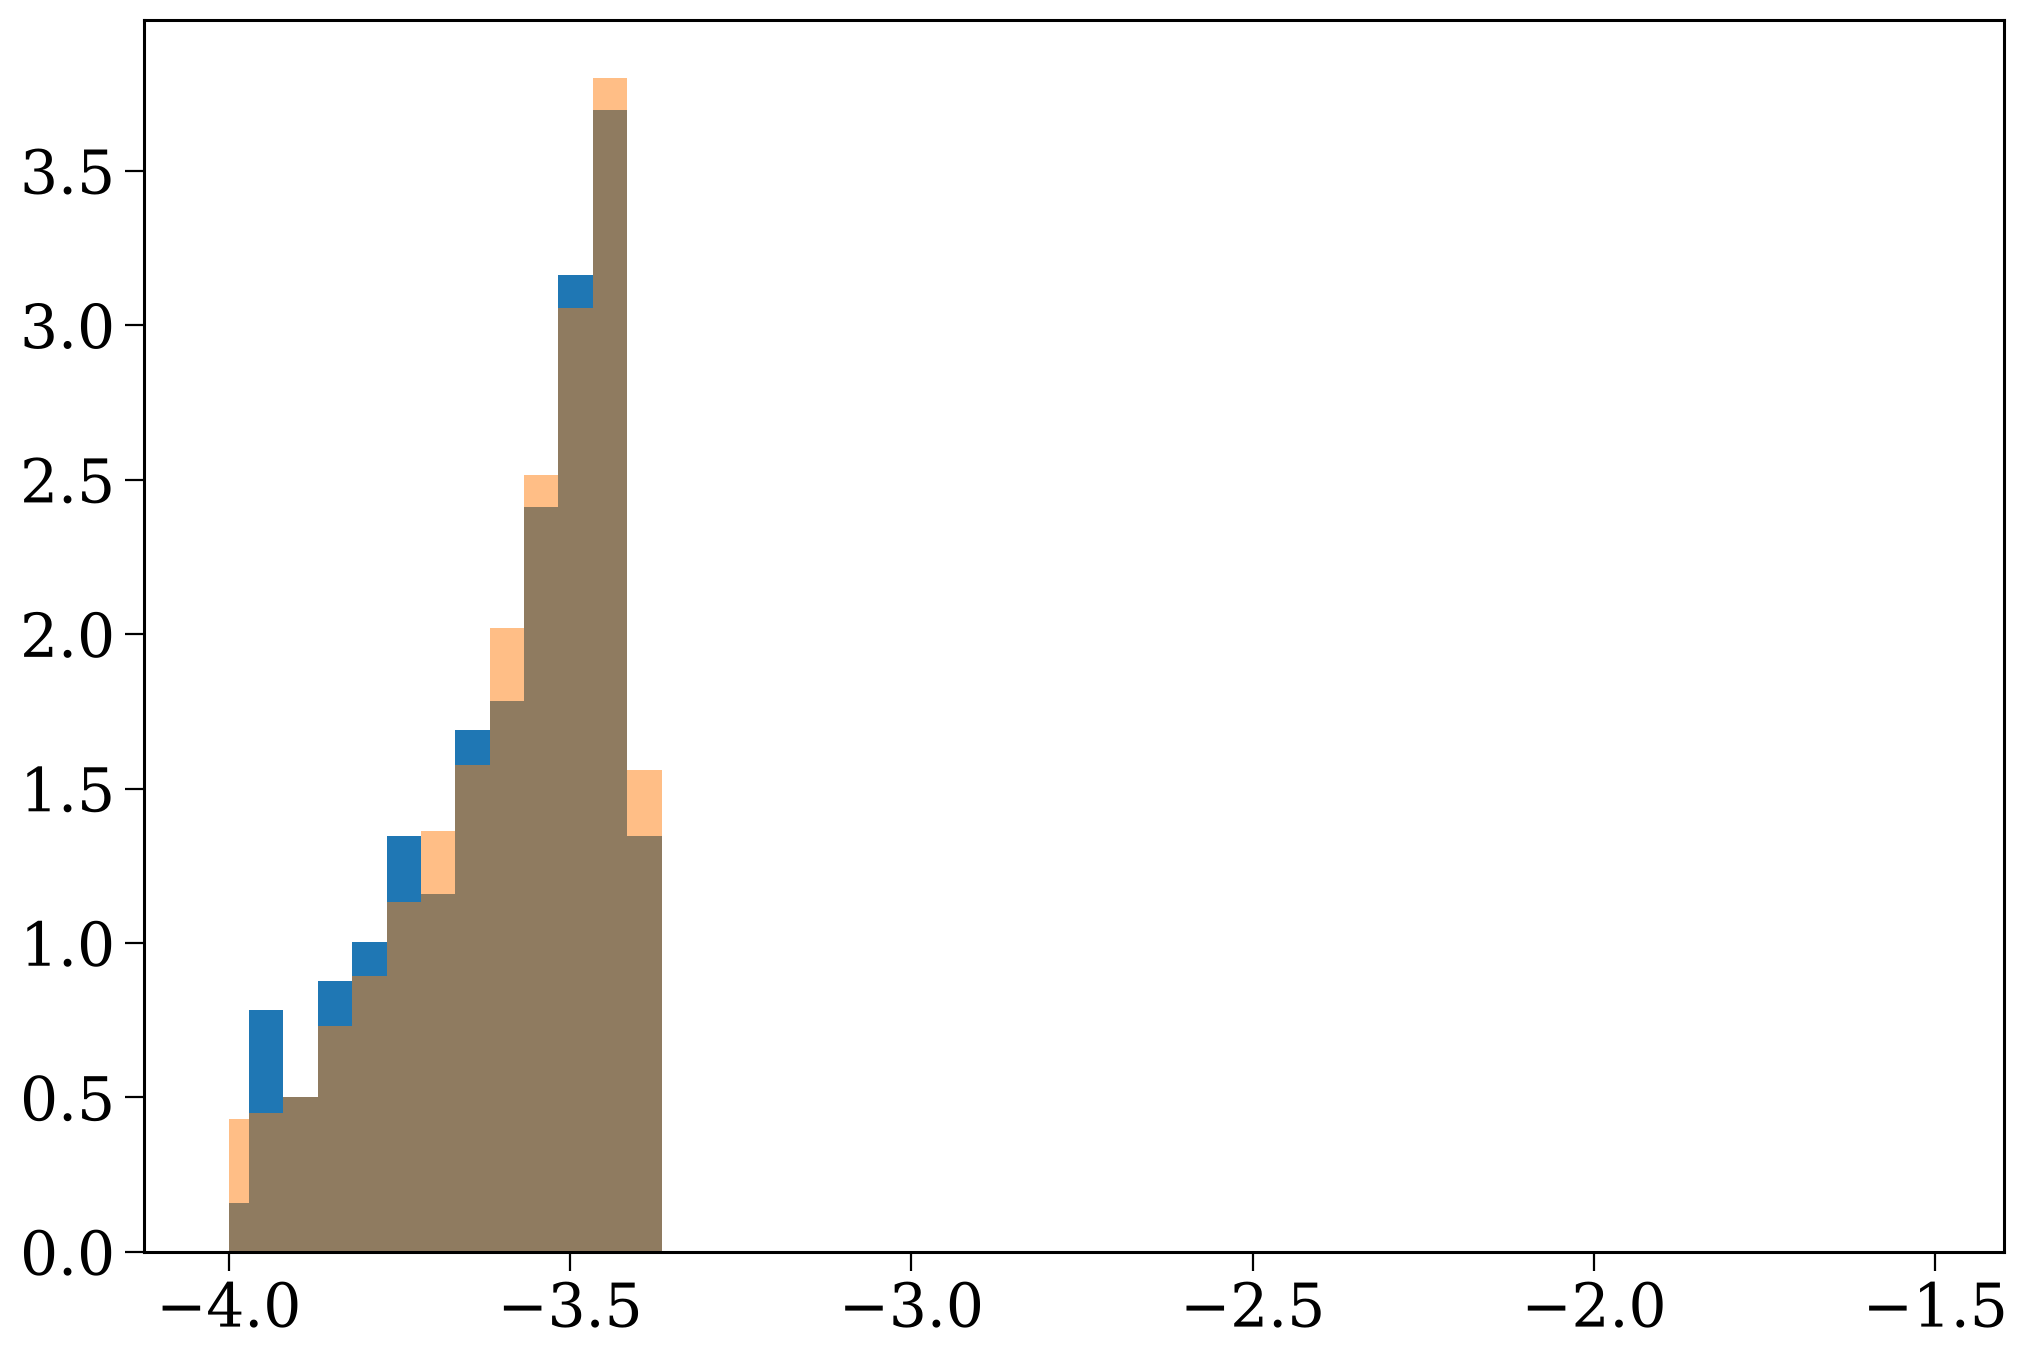

In [73]:
Z_LIM = 4e-4
print(f"Number of stars in MW: {len(mw.Z[mw.Z < Z_LIM])}")
print(f"Number of stars in MW with phi cut: {len(mw_cut.Z[mw_cut.Z < Z_LIM])}")
plt.hist(np.log10(mw.Z[mw.Z < Z_LIM]), bins=np.log10(const.Z_BIN_EDGES), density=True)
plt.hist(np.log10(mw_cut.Z[mw_cut.Z < Z_LIM]), bins=np.log10(const.Z_BIN_EDGES), alpha=0.5, density=True)

Number of stars in MW: 100000
Number of stars in MW with phi cut: 100000


(array([0.00213356, 0.00418972, 0.00628458, 0.00712252, 0.00544663,
        0.00754149, 0.00879841, 0.00837944, 0.01152172, 0.01906322,
        0.01885373, 0.02430036, 0.02849008, 0.03540311, 0.04064026,
        0.05362839, 0.05509479, 0.07206314, 0.09866785, 0.111237  ,
        0.12841485, 0.16151362, 0.19628827, 0.23085344, 0.28531977,
        0.32156083, 0.38650146, 0.43237887, 0.5046515 , 0.55932731,
        0.65108213, 0.72021247, 0.78745744, 0.86203441, 0.91021617,
        0.93619242, 0.98667852, 0.97180502, 1.0076271 , 0.9824888 ,
        0.95797895, 0.94080111, 0.87334665, 0.83940994, 0.81217677,
        0.74262746, 0.68292398, 0.58237076, 0.51952499, 0.44342524]),
 array([-4.        , -3.97032606, -3.91995578, -3.86958551, -3.81921523,
        -3.76884495, -3.71847467, -3.66810439, -3.61773411, -3.56736383,
        -3.51699355, -3.46662328, -3.416253  , -3.36588272, -3.31551244,
        -3.26514216, -3.21477188, -3.1644016 , -3.11403132, -3.06366105,
        -3.01329077, -2.96

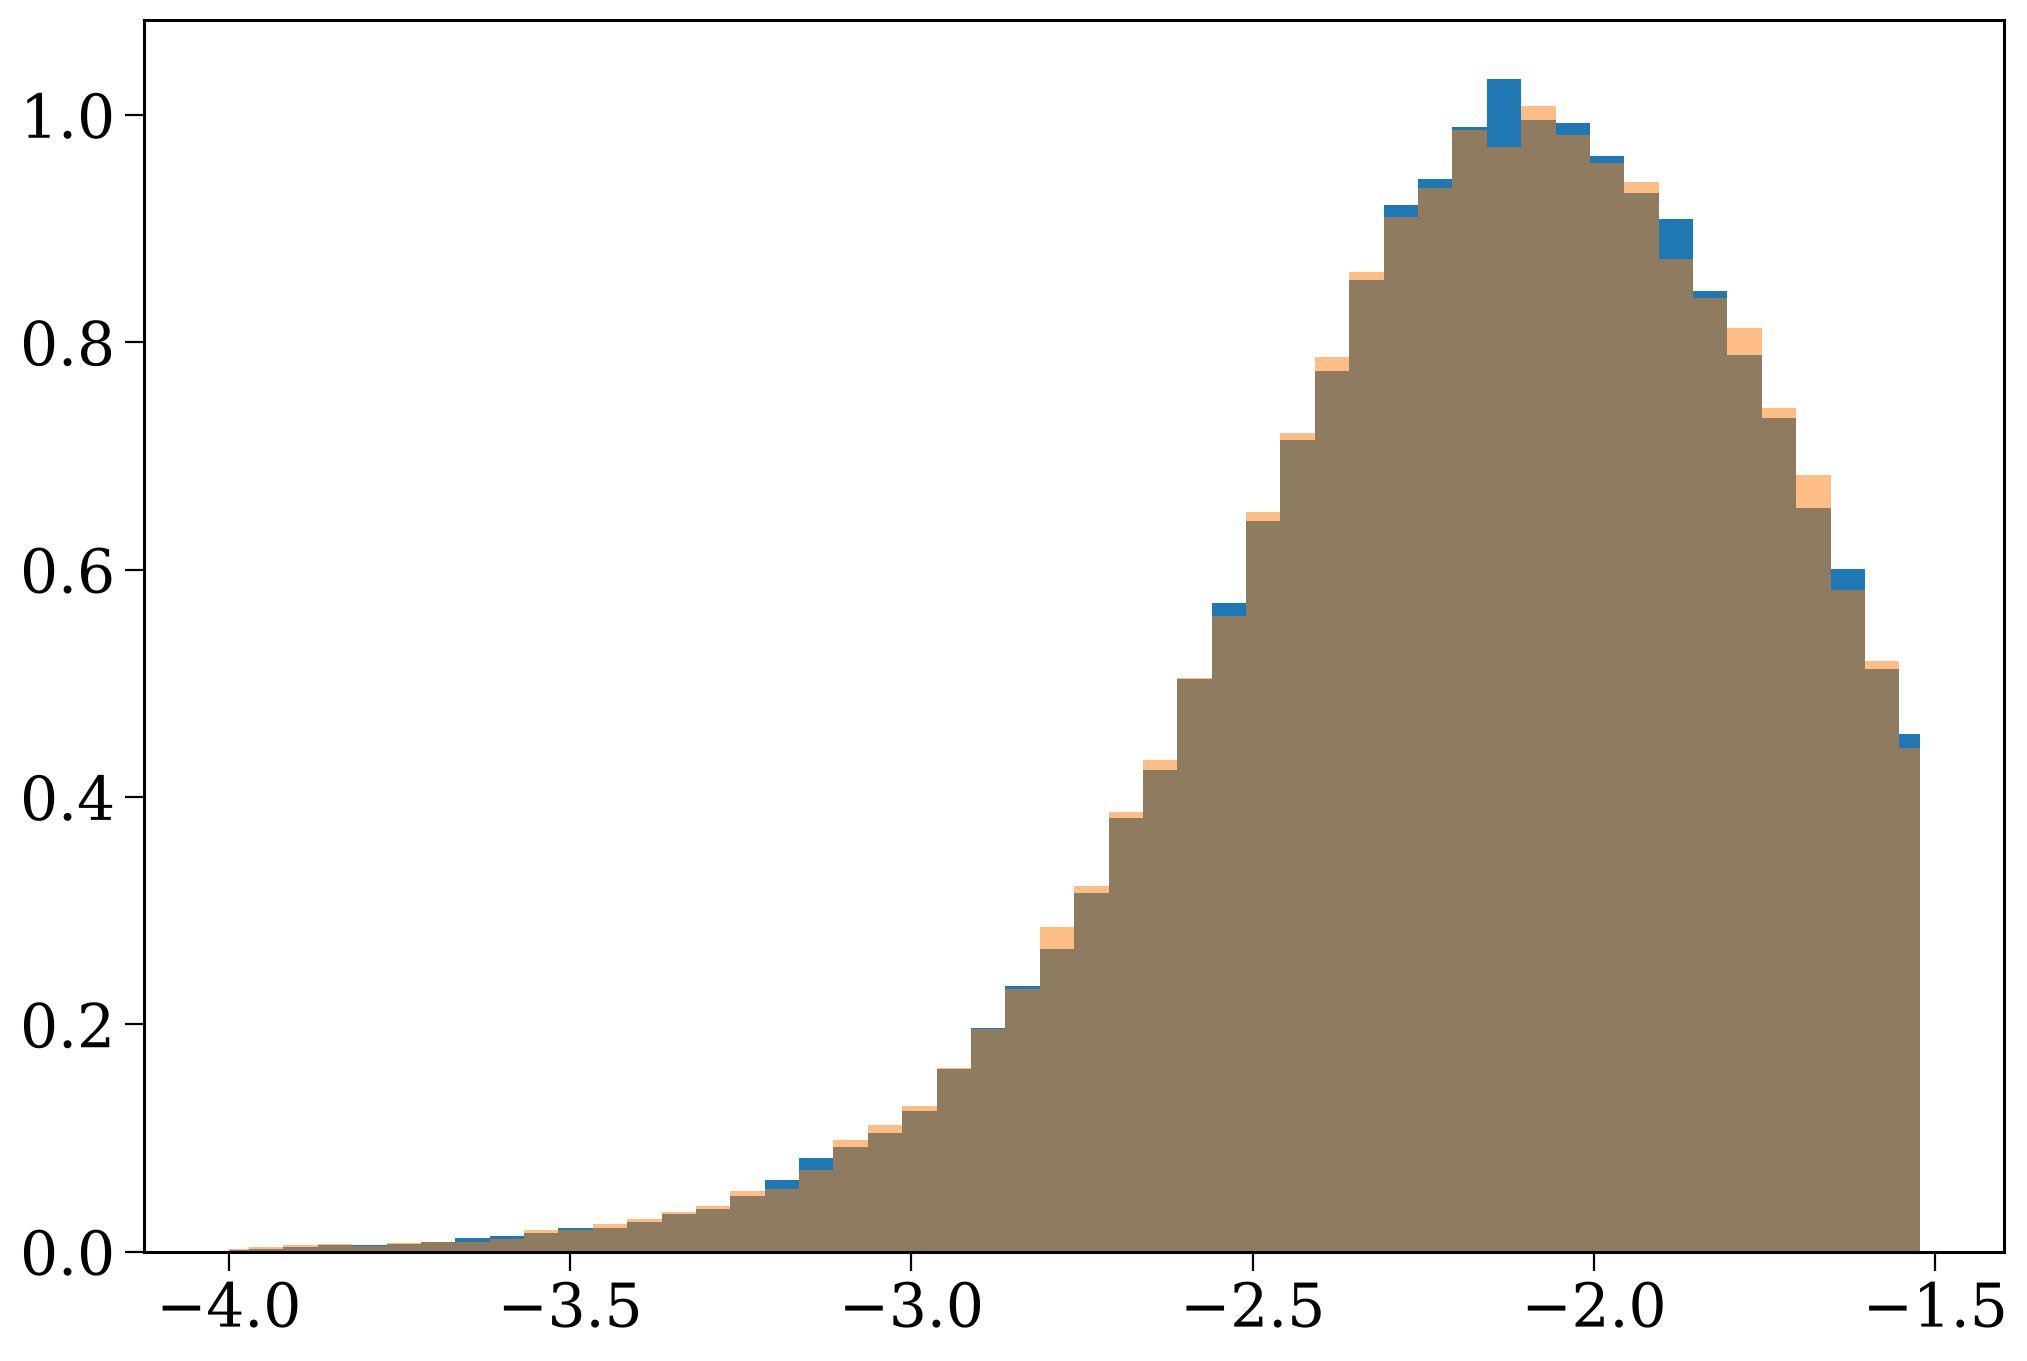

In [97]:
Z_LIM = 10
print(f"Number of stars in MW: {len(mw.Z[mw.Z < Z_LIM])}")
print(f"Number of stars in MW with phi cut: {len(mw_regular.Z[mw_regular.Z < Z_LIM])}")
plt.hist(np.log10(mw.Z[mw.Z < Z_LIM]), bins=np.log10(const.Z_BIN_EDGES), density=True)
plt.hist(np.log10(mw_regular.Z[mw_regular.Z < Z_LIM]), bins=np.log10(const.Z_BIN_EDGES), alpha=0.5, density=True)